# AE Comparison - Reconstruction vs Forecasting (Kuka anomaly detection)

Side-by-side evaluation of two AE *objectives* on the **same data, same architecture, same training budget**:

1. **Reconstruction AE** - input = window, target = window (classical AE baseline).
2. **Forecasting AE** - input = first 64 timesteps, target = next 64 (predict-next objective).

The only thing that changes is the training target. Everything else (data, splits, scaler, model, optimizer, epochs, patience, scoring rule, threshold rule, evaluation set) is held constant so any performance difference is attributable to the objective.

**Anomaly score**: `mean_MSE` per window - average squared error between the model's output and its target.

**Threshold rule (label-free)**: `mu + 2sigma` of `val_normal` scores. We also report ROC-AUC and PR-AUC (threshold-free).

**Final section**: side-by-side comparison table + bar chart.

## 1. Imports & config

In [1]:
import copy
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.metrics import (
    average_precision_score, classification_report, confusion_matrix,
    precision_recall_curve, roc_auc_score, roc_curve,
)

torch.manual_seed(42); np.random.seed(42)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

DATA_CANDIDATES = [
    Path.cwd(),
    Path.cwd() / "Data",
    Path.cwd().parent,
    Path.cwd().parent / "Data",
]
DATA_FOLDER = next(
    (folder for folder in DATA_CANDIDATES
     if (folder / "KukaNormal.npy").is_file() and (folder / "KukaSlow.npy").is_file()),
    None,
)
if DATA_FOLDER is None:
    checked = "\n".join(f"  - {folder.resolve()}" for folder in DATA_CANDIDATES)
    raise FileNotFoundError(
        "Could not find KukaNormal.npy and KukaSlow.npy. Checked:\n" + checked
    )
OUTPUT_DIR  = Path.cwd() / "outputs" / "ae_compare" / "unsupervised"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Data / window
WINDOW_LEN     = 128
STRIDE_TRAIN   = 32
STRIDE_EVAL    = 128
TRAIN_FRAC     = 0.70
VAL_FRAC       = 0.15
FORECAST_HALF  = WINDOW_LEN // 2          # 64 input / 64 target

# Model / training (identical for both AEs)
ENC_CHANNELS   = (64, 32)
BATCH_SIZE     = 256
EPOCHS         = 60
LEARNING_RATE  = 1e-3
PATIENCE       = 10
GRAD_CLIP      = 1.0
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("device :", DEVICE)
print("PyTorch:", torch.__version__)

device : cuda
PyTorch: 2.5.1+cu121


## 2. Data pipeline (shared)

Load -> drop `action` column -> time-aware split (70/15/15) -> min-max scaling to `[-1, 1]` with clipping -> sliding windows `(N, F, L)`.

We then build **two parallel tensor sets** from the same windows:

- **Reconstruction**: `(input, target) = (W, W)` - predict the window from itself.
- **Forecasting**: `(input, target) = (W[:, :, :64], W[:, :, 64:128])` - predict the next 64 timesteps from the first 64.

Same windows -> same evaluation set -> fair comparison.

In [2]:
# --- load + drop action -------------------------------------------------
kuka_normal = np.load(DATA_FOLDER / "KukaNormal.npy").astype(np.float32)
kuka_slow   = np.load(DATA_FOLDER / "KukaSlow.npy").astype(np.float32)

X_normal = kuka_normal[:, 1:]                  # drop column 0 ("action")
X_slow   = kuka_slow[:, :-1][:, 1:]            # drop "anomaly" label, drop "action"
n_features = X_normal.shape[1]
print(f"X_normal: {X_normal.shape}   X_slow: {X_slow.shape}   n_features: {n_features}")

# --- time-aware split on normal -----------------------------------------
T = X_normal.shape[0]
nt = int(T * TRAIN_FRAC); nv = int(T * VAL_FRAC)
train_raw = X_normal[:nt]
val_raw   = X_normal[nt:nt + nv]
test_raw  = X_normal[nt + nv:]
print(f"train: {train_raw.shape}   val: {val_raw.shape}   test: {test_raw.shape}")

# --- min-max [-1, 1] with clip ------------------------------------------
def fit_minmax(X, feature_range=(-1.0, 1.0), eps=1e-8):
    mn = X.min(axis=0).astype(np.float32)
    mx = X.max(axis=0).astype(np.float32)
    span = np.maximum(mx - mn, eps)
    lo, hi = feature_range
    a = ((hi - lo) / span).astype(np.float32)
    b = (lo - mn * a).astype(np.float32)
    return a, b

def apply_minmax(X, a, b, fr=(-1.0, 1.0)):
    return np.clip(X * a + b, fr[0], fr[1]).astype(np.float32)

a, b = fit_minmax(train_raw)
train_s = apply_minmax(train_raw, a, b)
val_s   = apply_minmax(val_raw,   a, b)
test_s  = apply_minmax(test_raw,  a, b)
slow_s  = apply_minmax(X_slow,    a, b)

# --- sliding windows (N, F, L) ------------------------------------------
def make_windows(x, window_len, stride):
    T = x.shape[0]
    n = (T - window_len) // stride + 1
    idx = np.arange(window_len)[None, :] + stride * np.arange(n)[:, None]
    return np.transpose(x[idx], (0, 2, 1)).astype(np.float32)        # (N, F, L)

W_train = torch.from_numpy(make_windows(train_s, WINDOW_LEN, STRIDE_TRAIN))
W_val   = torch.from_numpy(make_windows(val_s,   WINDOW_LEN, STRIDE_EVAL))
W_test  = torch.from_numpy(make_windows(test_s,  WINDOW_LEN, STRIDE_EVAL))
W_slow  = torch.from_numpy(make_windows(slow_s,  WINDOW_LEN, STRIDE_EVAL))

print(f"\nwindows  train={tuple(W_train.shape)}  val={tuple(W_val.shape)}  "
      f"test={tuple(W_test.shape)}  slow={tuple(W_slow.shape)}")

# --- forecast pairs: first 64 = input, next 64 = target -----------------
def split_pair(X_BFL, h):
    return X_BFL[:, :, :h].contiguous(), X_BFL[:, :, h:h * 2].contiguous()

X_train_in, X_train_tg = split_pair(W_train, FORECAST_HALF)
X_val_in,   X_val_tg   = split_pair(W_val,   FORECAST_HALF)
X_test_in,  X_test_tg  = split_pair(W_test,  FORECAST_HALF)
X_slow_in,  X_slow_tg  = split_pair(W_slow,  FORECAST_HALF)

# --- DataLoaders: input/target pairs (recon uses W,W ; forecast uses in,tg)
recon_train_loader = DataLoader(
    TensorDataset(W_train, W_train), batch_size=BATCH_SIZE, shuffle=True)
recon_val_loader   = DataLoader(
    TensorDataset(W_val,   W_val),   batch_size=BATCH_SIZE, shuffle=False)

forecast_train_loader = DataLoader(
    TensorDataset(X_train_in, X_train_tg), batch_size=BATCH_SIZE, shuffle=True)
forecast_val_loader   = DataLoader(
    TensorDataset(X_val_in,   X_val_tg),   batch_size=BATCH_SIZE, shuffle=False)

print(f"forecast pairs   in/target each = {tuple(X_train_in.shape)} (train)")

X_normal: (233792, 85)   X_slow: (41538, 85)   n_features: 85
train: (163654, 85)   val: (35068, 85)   test: (35070, 85)

windows  train=(5111, 85, 128)  val=(273, 85, 128)  test=(273, 85, 128)  slow=(324, 85, 128)
forecast pairs   in/target each = (5111, 85, 64) (train)


## 3. Shared model & training helper

The same `ConvAE1D` (2-block, channels `64 -> 32`, `tanh` output) is used for both AEs. The training helper takes any `(input, target)` loader and runs an identical training loop - so the only thing that differs between the two AEs is *what data is fed in*.

In [3]:
class ConvAE1D(nn.Module):
    def __init__(self, n_features, enc_channels=(64, 32)):
        super().__init__()
        c1, c2 = enc_channels
        self.encoder = nn.Sequential(
            nn.Conv1d(n_features, c1, 3, padding=1), nn.ReLU(inplace=True), nn.MaxPool1d(2),
            nn.Conv1d(c1, c2, 3, padding=1),         nn.ReLU(inplace=True), nn.MaxPool1d(2),
        )
        self.decoder = nn.Sequential(
            nn.Upsample(scale_factor=2, mode="nearest"),
            nn.Conv1d(c2, c2, 3, padding=1), nn.ReLU(inplace=True),
            nn.Upsample(scale_factor=2, mode="nearest"),
            nn.Conv1d(c2, c1, 3, padding=1), nn.ReLU(inplace=True),
            nn.Conv1d(c1, n_features, 3, padding=1),
            nn.Tanh(),
        )

    def encode(self, x): return self.encoder(x)
    def decode(self, z): return self.decoder(z)
    def forward(self, x): return self.decode(self.encode(x))


def run_epoch(model, loader, loss_fn, device, optimizer=None, grad_clip=None):
    is_train = optimizer is not None
    model.train(is_train)
    total, n = 0.0, 0
    for xi, xt in loader:
        xi = xi.to(device, non_blocking=True)
        xt = xt.to(device, non_blocking=True)
        loss = loss_fn(model(xi), xt)
        if is_train:
            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            if grad_clip is not None:
                nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            optimizer.step()
        total += loss.item() * xi.size(0); n += xi.size(0)
    return total / max(n, 1)


def train_model(train_loader, val_loader, *, tag, seed=42):
    """Build a fresh ConvAE1D, train with early stopping. Returns (model, train_losses, val_losses, best_val)."""
    torch.manual_seed(seed); np.random.seed(seed)
    model = ConvAE1D(n_features=n_features, enc_channels=ENC_CHANNELS).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    loss_fn   = nn.MSELoss()
    n_params  = sum(p.numel() for p in model.parameters())
    print(f"[{tag}] ConvAE1D  params={n_params:,}  enc={ENC_CHANNELS}")

    train_losses, val_losses = [], []
    best_val, best_state, remaining = float("inf"), None, PATIENCE
    for epoch in range(1, EPOCHS + 1):
        tr = run_epoch(model, train_loader, loss_fn, DEVICE, optimizer, GRAD_CLIP)
        with torch.no_grad():
            va = run_epoch(model, val_loader, loss_fn, DEVICE, optimizer=None)
        train_losses.append(tr); val_losses.append(va)
        improved = va < best_val - 1e-6
        if improved:
            best_val = va
            best_state = copy.deepcopy(model.state_dict())
            remaining = PATIENCE
        print(f"  [{tag}] epoch {epoch:03d} | train {tr:.6f} | val {va:.6f}{' *' if improved else ''}")
        if not improved:
            remaining -= 1
            if remaining <= 0:
                print(f"  [{tag}] Early stop at epoch {epoch} (best val {best_val:.6f})")
                break

    model.load_state_dict(best_state)
    return model, train_losses, val_losses, best_val


@torch.no_grad()
def score_mean_mse(model, x_in, x_tg, batch_size=256, device=DEVICE):
    """One scalar per window: average squared error between model(x_in) and x_tg."""
    model.eval()
    out = []
    for i in range(0, x_in.shape[0], batch_size):
        xi = x_in[i:i + batch_size].to(device)
        xt = x_tg[i:i + batch_size].to(device)
        out.append((model(xi) - xt).pow(2).mean(dim=(1, 2)).cpu().numpy())
    return np.concatenate(out)


def evaluate_scores(sv, st, ss, *, tag):
    """Given val_normal / test_normal / slow scores, return a dict with ROC, PR, threshold, CM, F1 panel."""
    y_eval = np.concatenate([np.zeros(st.size, np.int64), np.ones(ss.size, np.int64)])
    s_eval = np.concatenate([st, ss])

    roc_auc = float(roc_auc_score(y_eval, s_eval))
    pr_auc  = float(average_precision_score(y_eval, s_eval))

    rules = {
        "mu+2sigma": float(sv.mean() + 2.0 * sv.std()),
        "p90": float(np.percentile(sv, 90)),
        "p95": float(np.percentile(sv, 95)),
        "p99": float(np.percentile(sv, 99)),
    }
    panel = {}
    for name, thr in rules.items():
        pred = (s_eval > thr).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_eval, pred, labels=[0, 1]).ravel()
        P = tp / max(tp + fp, 1); R = tp / max(tp + fn, 1)
        F1 = (2 * P * R / max(P + R, 1e-12)) if (P + R) > 0 else 0.0
        panel[name] = {"thr": float(thr), "P": float(P), "R": float(R), "F1": float(F1),
                       "tp": int(tp), "fp": int(fp), "tn": int(tn), "fn": int(fn)}

    headline = panel["mu+2sigma"]
    return {
        "tag": tag,
        "roc_auc": roc_auc,
        "pr_auc":  pr_auc,
        "threshold": headline["thr"],
        "operating_points": panel,
        "y_eval": y_eval, "s_eval": s_eval,
        "sv": sv, "st": st, "ss": ss,
    }


def print_headline(res):
    y, s, thr = res["y_eval"], res["s_eval"], res["threshold"]
    pred = (s > thr).astype(int)
    cm = confusion_matrix(y, pred, labels=[0, 1])
    print(f"[{res['tag']}]  ROC-AUC = {res['roc_auc']:.4f}   PR-AUC = {res['pr_auc']:.4f}")
    print(f"[{res['tag']}]  Threshold (val_normal mu+2sigma) = {thr:.6f}")
    print()
    print(f"               pred normal | pred anomaly")
    print(f"actual normal      {cm[0,0]:5d}        {cm[0,1]:5d}")
    print(f"actual anomaly     {cm[1,0]:5d}        {cm[1,1]:5d}")
    print()
    print(classification_report(y, pred, target_names=["normal", "anomaly"], digits=3))


def plot_diagnostics(res, score_label):
    y, s, thr = res["y_eval"], res["s_eval"], res["threshold"]
    st, ss = res["st"], res["ss"]
    pred = (s > thr).astype(int)
    cm = confusion_matrix(y, pred, labels=[0, 1])

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle(f"{res['tag']}  |  ROC={res['roc_auc']:.3f}  PR={res['pr_auc']:.3f}", y=1.02)

    ax = axes[0]
    ax.hist(st, bins=60, alpha=0.55, density=True, label="normal (test)")
    ax.hist(ss, bins=60, alpha=0.55, density=True, label="anomalous (slow)")
    ax.axvline(thr, color="red", linestyle="--", label=f"thr (mu+2sigma)={thr:.4f}")
    ax.set_yscale("log")
    ax.set_xlabel(score_label); ax.set_ylabel("density")
    ax.set_title("Score distribution"); ax.legend(fontsize=8)

    ax = axes[1]
    fpr, tpr, _ = roc_curve(y, s)
    prec, rec, _ = precision_recall_curve(y, s)
    ax.plot(fpr, tpr, label=f"ROC (AUC={res['roc_auc']:.3f})")
    ax.plot(rec, prec, label=f"PR  (AUC={res['pr_auc']:.3f})", linestyle="--")
    ax.plot([0, 1], [0, 1], "k:", alpha=0.4)
    ax.set_xlabel("FPR / Recall"); ax.set_ylabel("TPR / Precision")
    ax.set_title("ROC + PR curves"); ax.legend(fontsize=8)

    ax = axes[2]
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(["pred normal", "pred anomaly"])
    ax.set_yticklabels(["actual normal", "actual anomaly"])
    for (i, j), v in np.ndenumerate(cm):
        ax.text(j, i, str(v), ha="center", va="center",
                color="white" if v > cm.max() / 2 else "black", fontsize=12)
    ax.set_title("Confusion matrix")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    plt.tight_layout(); plt.show()


print("helpers ready")

helpers ready


## 4. Reconstruction AE - the classical baseline

Input = window, target = same window. The model learns to *compress and reconstruct* normal behaviour. Anomalies are detected as windows the AE cannot reconstruct well.

[recon AE] ConvAE1D  params=48,277  enc=(64, 32)
  [recon AE] epoch 001 | train 0.174711 | val 0.118908 *
  [recon AE] epoch 002 | train 0.105636 | val 0.103597 *
  [recon AE] epoch 003 | train 0.078272 | val 0.085670 *
  [recon AE] epoch 004 | train 0.056879 | val 0.070867 *
  [recon AE] epoch 005 | train 0.043149 | val 0.061866 *
  [recon AE] epoch 006 | train 0.033365 | val 0.052610 *
  [recon AE] epoch 007 | train 0.026105 | val 0.044943 *
  [recon AE] epoch 008 | train 0.022726 | val 0.042294 *
  [recon AE] epoch 009 | train 0.021409 | val 0.039967 *
  [recon AE] epoch 010 | train 0.020213 | val 0.038049 *
  [recon AE] epoch 011 | train 0.019006 | val 0.035505 *
  [recon AE] epoch 012 | train 0.018273 | val 0.034704 *
  [recon AE] epoch 013 | train 0.017270 | val 0.033373 *
  [recon AE] epoch 014 | train 0.016772 | val 0.032011 *
  [recon AE] epoch 015 | train 0.016071 | val 0.031479 *
  [recon AE] epoch 016 | train 0.015238 | val 0.030621 *
  [recon AE] epoch 017 | train 0.014747

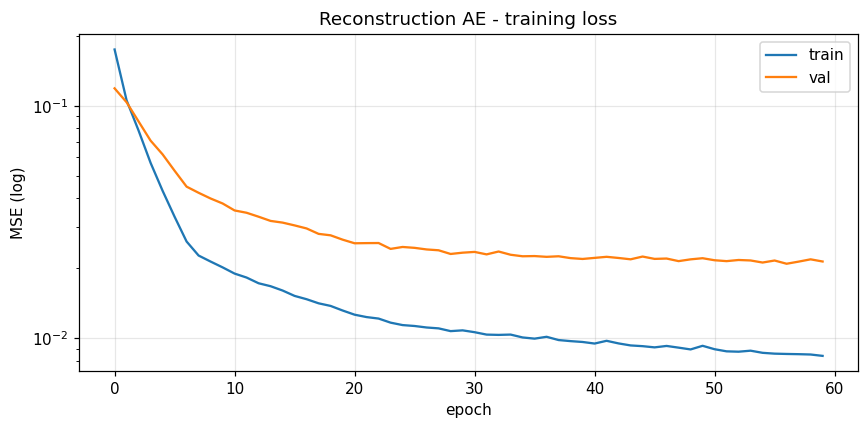

In [4]:
recon_model, recon_tr_losses, recon_va_losses, recon_best_val = train_model(
    recon_train_loader, recon_val_loader, tag="recon AE")

torch.save({"model_state": recon_model.state_dict(),
            "train_losses": recon_tr_losses, "val_losses": recon_va_losses,
            "config": {"window_len": WINDOW_LEN, "objective": "reconstruction",
                       "enc_channels": list(ENC_CHANNELS),
                       "batch_size": BATCH_SIZE, "lr": LEARNING_RATE,
                       "epochs_run": len(recon_tr_losses),
                       "best_val": recon_best_val}},
           OUTPUT_DIR / "recon_ae.pt")
print("saved ->", OUTPUT_DIR / "recon_ae.pt")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(recon_tr_losses, label="train"); ax.plot(recon_va_losses, label="val")
ax.set_yscale("log"); ax.set_xlabel("epoch"); ax.set_ylabel("MSE (log)")
ax.set_title("Reconstruction AE - training loss"); ax.legend()
plt.tight_layout(); plt.show()

val_normal   n= 273  mean=0.02095  p99=0.03440
test_normal  n= 273  mean=0.01685  p99=0.03211
slow         n= 324  mean=0.02014  p99=0.04853

[Reconstruction AE]  ROC-AUC = 0.4659   PR-AUC = 0.6889
[Reconstruction AE]  Threshold (val_normal mu+2sigma) = 0.033604

               pred normal | pred anomaly
actual normal        273            0
actual anomaly       251           73

              precision    recall  f1-score   support

      normal      0.521     1.000     0.685       273
     anomaly      1.000     0.225     0.368       324

    accuracy                          0.580       597
   macro avg      0.760     0.613     0.526       597
weighted avg      0.781     0.580     0.513       597



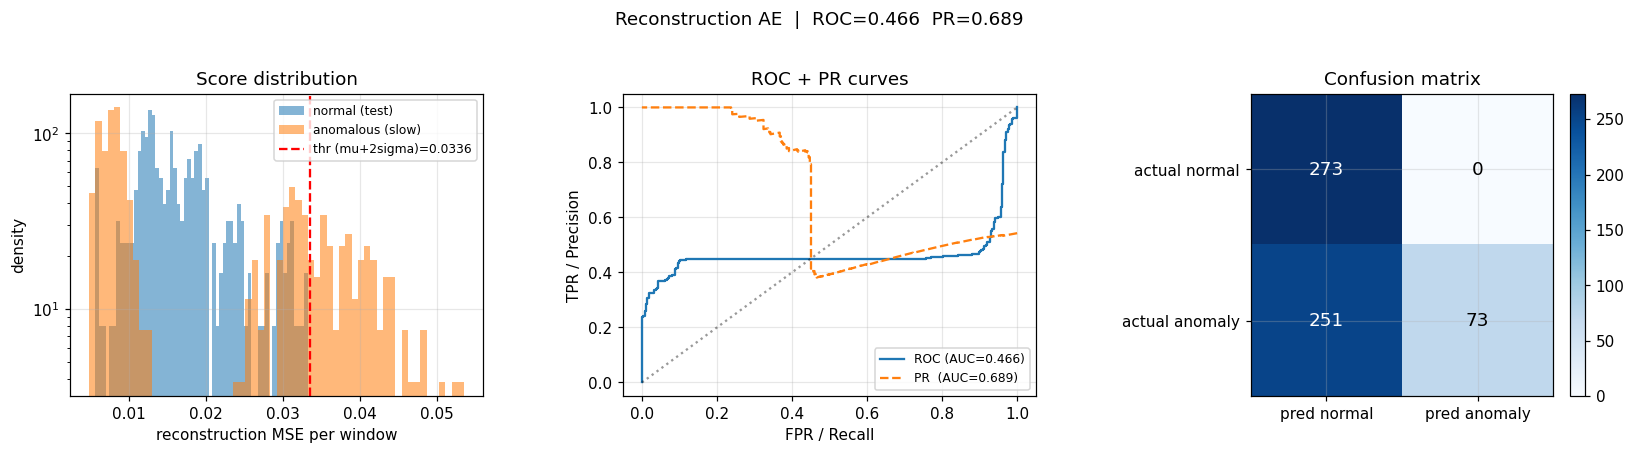

In [5]:
# Reconstruction score = mean MSE between W and model(W).
recon_sv = score_mean_mse(recon_model, W_val,  W_val)
recon_st = score_mean_mse(recon_model, W_test, W_test)
recon_ss = score_mean_mse(recon_model, W_slow, W_slow)

print(f"val_normal   n={recon_sv.size:4d}  mean={recon_sv.mean():.5f}  p99={np.percentile(recon_sv, 99):.5f}")
print(f"test_normal  n={recon_st.size:4d}  mean={recon_st.mean():.5f}  p99={np.percentile(recon_st, 99):.5f}")
print(f"slow         n={recon_ss.size:4d}  mean={recon_ss.mean():.5f}  p99={np.percentile(recon_ss, 99):.5f}")
print()

recon_res = evaluate_scores(recon_sv, recon_st, recon_ss, tag="Reconstruction AE")
print_headline(recon_res)
plot_diagnostics(recon_res, score_label="reconstruction MSE per window")

## 5. Forecasting AE - predict next from past

Input = first 64 timesteps of the window, target = next 64. Same network, same loss, same training budget. The model learns to predict near-future dynamics from recent past. Anomalies show up as windows where the future is *hard to predict* from the past.

[forecast AE] ConvAE1D  params=48,277  enc=(64, 32)
  [forecast AE] epoch 001 | train 0.176333 | val 0.121797 *
  [forecast AE] epoch 002 | train 0.109270 | val 0.110809 *
  [forecast AE] epoch 003 | train 0.088061 | val 0.101675 *
  [forecast AE] epoch 004 | train 0.071211 | val 0.088658 *
  [forecast AE] epoch 005 | train 0.056454 | val 0.077511 *
  [forecast AE] epoch 006 | train 0.045001 | val 0.068821 *
  [forecast AE] epoch 007 | train 0.039577 | val 0.060663 *
  [forecast AE] epoch 008 | train 0.037113 | val 0.060366 *
  [forecast AE] epoch 009 | train 0.036012 | val 0.057662 *
  [forecast AE] epoch 010 | train 0.034621 | val 0.055625 *
  [forecast AE] epoch 011 | train 0.033685 | val 0.054957 *
  [forecast AE] epoch 012 | train 0.032808 | val 0.053344 *
  [forecast AE] epoch 013 | train 0.031922 | val 0.053415
  [forecast AE] epoch 014 | train 0.031265 | val 0.051322 *
  [forecast AE] epoch 015 | train 0.030419 | val 0.049208 *
  [forecast AE] epoch 016 | train 0.029916 | val 0

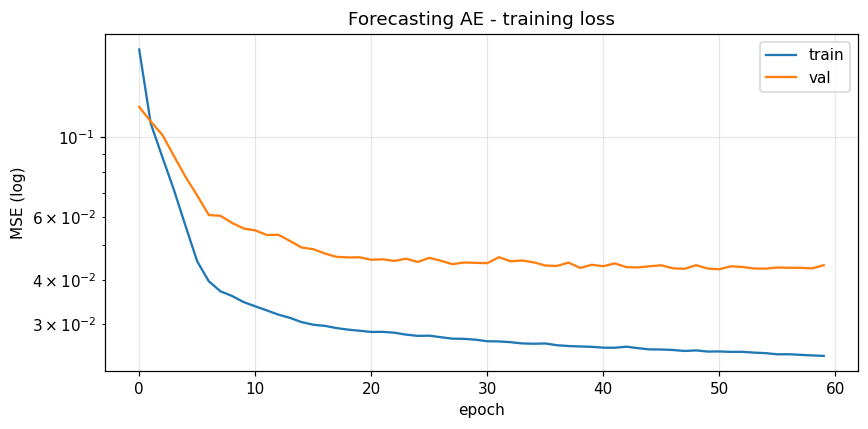

In [6]:
fc_model, fc_tr_losses, fc_va_losses, fc_best_val = train_model(
    forecast_train_loader, forecast_val_loader, tag="forecast AE")

torch.save({"model_state": fc_model.state_dict(),
            "train_losses": fc_tr_losses, "val_losses": fc_va_losses,
            "config": {"window_len": WINDOW_LEN, "objective": "forecast",
                       "forecast_half": FORECAST_HALF,
                       "enc_channels": list(ENC_CHANNELS),
                       "batch_size": BATCH_SIZE, "lr": LEARNING_RATE,
                       "epochs_run": len(fc_tr_losses),
                       "best_val": fc_best_val}},
           OUTPUT_DIR / "forecast_ae.pt")
print("saved ->", OUTPUT_DIR / "forecast_ae.pt")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(fc_tr_losses, label="train"); ax.plot(fc_va_losses, label="val")
ax.set_yscale("log"); ax.set_xlabel("epoch"); ax.set_ylabel("MSE (log)")
ax.set_title("Forecasting AE - training loss"); ax.legend()
plt.tight_layout(); plt.show()

val_normal   n= 273  mean=0.04278  p99=0.09286
test_normal  n= 273  mean=0.04216  p99=0.07724
slow         n= 324  mean=0.05959  p99=0.10297

[Forecasting AE]  ROC-AUC = 0.6512   PR-AUC = 0.7788
[Forecasting AE]  Threshold (val_normal mu+2sigma) = 0.068331

               pred normal | pred anomaly
actual normal        259           14
actual anomaly       177          147

              precision    recall  f1-score   support

      normal      0.594     0.949     0.731       273
     anomaly      0.913     0.454     0.606       324

    accuracy                          0.680       597
   macro avg      0.754     0.701     0.668       597
weighted avg      0.767     0.680     0.663       597



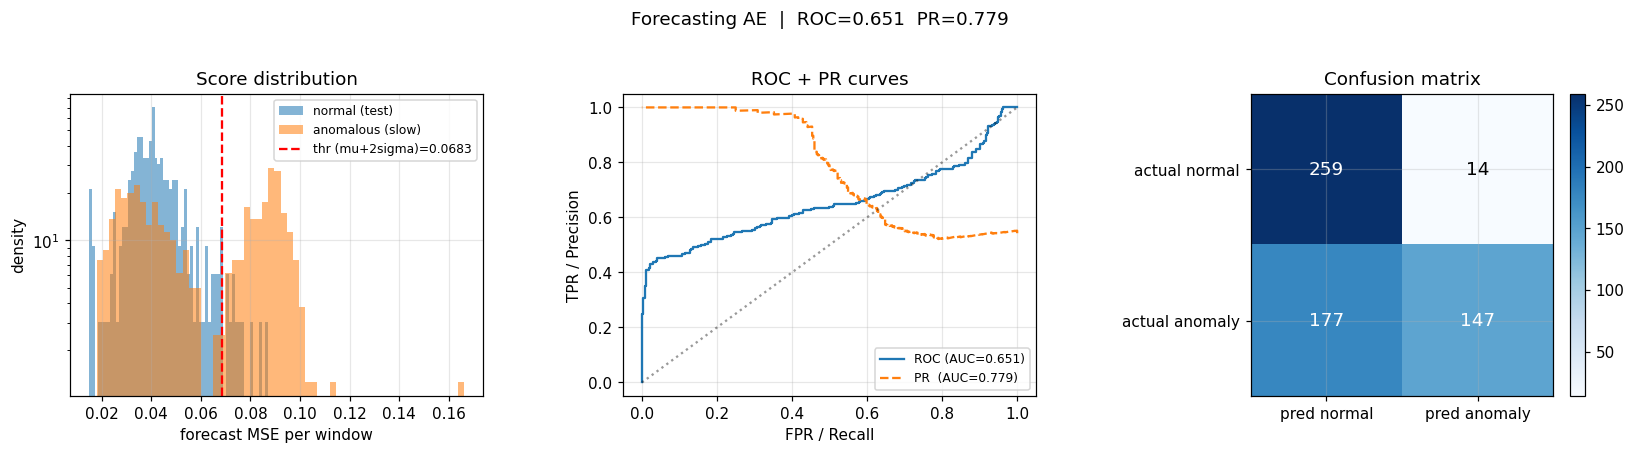

In [7]:
# Forecasting score = mean MSE between model(first 64) and next 64.
fc_sv = score_mean_mse(fc_model, X_val_in,  X_val_tg)
fc_st = score_mean_mse(fc_model, X_test_in, X_test_tg)
fc_ss = score_mean_mse(fc_model, X_slow_in, X_slow_tg)

print(f"val_normal   n={fc_sv.size:4d}  mean={fc_sv.mean():.5f}  p99={np.percentile(fc_sv, 99):.5f}")
print(f"test_normal  n={fc_st.size:4d}  mean={fc_st.mean():.5f}  p99={np.percentile(fc_st, 99):.5f}")
print(f"slow         n={fc_ss.size:4d}  mean={fc_ss.mean():.5f}  p99={np.percentile(fc_ss, 99):.5f}")
print()

fc_res = evaluate_scores(fc_sv, fc_st, fc_ss, tag="Forecasting AE")
print_headline(fc_res)
plot_diagnostics(fc_res, score_label="forecast MSE per window")

## 6. Final comparison

Side-by-side comparison of both objectives. Threshold-free metrics (ROC-AUC, PR-AUC) are the primary numbers - they don't depend on a threshold and are not subject to label leakage. F1 / P / R at `mu + 2sigma` of `val_normal` are reported as a label-free operating point.

                 model |  ROC-AUC |  PR-AUC | thr (mu+2sig) |     P     R    F1 |  TP  FP  TN  FN
----------------------------------------------------------------------------------------------------
     Reconstruction AE |   0.4659 |  0.6889 |       0.03360 | 1.000 0.225 0.368 |  73   0 273 251
        Forecasting AE |   0.6512 |  0.7788 |       0.06833 | 0.913 0.454 0.606 | 147  14 259 177


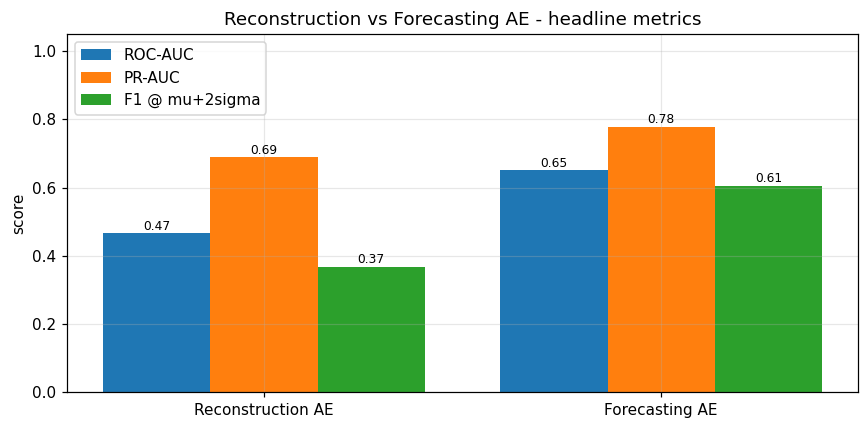


saved -> c:\Users\siava\Desktop\4th_Semester\ML-App\project-AM01\github_version\ML_APP_Anomaly_Detection\outputs\ae_compare\unsupervised\compare_final.json

ROC-AUC winner: Forecasting AE  (0.651)
PR-AUC  winner: Forecasting AE


In [8]:
results = [recon_res, fc_res]

# ---------------- side-by-side text table ------------------------------
print(f"{'model':>22s} | {'ROC-AUC':>8s} | {'PR-AUC':>7s} | "
      f"{'thr (mu+2sig)':>13s} | {'P':>5s} {'R':>5s} {'F1':>5s} | "
      f"{'TP':>3s} {'FP':>3s} {'TN':>3s} {'FN':>3s}")
print("-" * 100)
for r in results:
    op = r["operating_points"]["mu+2sigma"]
    print(f"{r['tag']:>22s} | {r['roc_auc']:8.4f} | {r['pr_auc']:7.4f} | "
          f"{r['threshold']:13.5f} | {op['P']:5.3f} {op['R']:5.3f} {op['F1']:5.3f} | "
          f"{op['tp']:3d} {op['fp']:3d} {op['tn']:3d} {op['fn']:3d}")

# ---------------- bar chart of ROC-AUC and PR-AUC ----------------------
labels = [r["tag"] for r in results]
roc = [r["roc_auc"] for r in results]
pr  = [r["pr_auc"]  for r in results]
f1  = [r["operating_points"]["mu+2sigma"]["F1"] for r in results]

x = np.arange(len(labels)); w = 0.27
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x - w, roc, width=w, label="ROC-AUC")
ax.bar(x,     pr,  width=w, label="PR-AUC")
ax.bar(x + w, f1,  width=w, label="F1 @ mu+2sigma")
for i, v in enumerate(roc): ax.text(i - w, v + 0.01, f"{v:.2f}", ha="center", fontsize=8)
for i, v in enumerate(pr):  ax.text(i,     v + 0.01, f"{v:.2f}", ha="center", fontsize=8)
for i, v in enumerate(f1):  ax.text(i + w, v + 0.01, f"{v:.2f}", ha="center", fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylim(0.0, 1.05); ax.set_ylabel("score")
ax.set_title("Reconstruction vs Forecasting AE - headline metrics")
ax.legend(); plt.tight_layout(); plt.show()

# ---------------- save comparison JSON ---------------------------------
summary = {
    "config": {
        "window_len": WINDOW_LEN, "forecast_half": FORECAST_HALF,
        "enc_channels": list(ENC_CHANNELS), "batch_size": BATCH_SIZE,
        "epochs_cap": EPOCHS, "patience": PATIENCE, "lr": LEARNING_RATE,
        "data": "KukaNormal (action dropped, 85 features)",
        "n_test_normal": int(recon_st.size), "n_test_anomaly": int(recon_ss.size),
    },
    "models": {
        r["tag"]: {
            "roc_auc": r["roc_auc"],
            "pr_auc":  r["pr_auc"],
            "operating_points": r["operating_points"],
        } for r in results
    },
}
with open(OUTPUT_DIR / "compare_final.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2, default=float)
print("\nsaved ->", OUTPUT_DIR / "compare_final.json")

# ---------------- one-line takeaway ------------------------------------
winner = max(results, key=lambda r: r["roc_auc"])
print(f"\nROC-AUC winner: {winner['tag']}  ({winner['roc_auc']:.3f})")
print(f"PR-AUC  winner: {max(results, key=lambda r: r['pr_auc'])['tag']}")

## 7. AAE - Adversarial Autoencoder (Pix2Pix-style)

We add a **discriminator** that judges whether a window is "real normal data" or "an AE reconstruction". The generator (= our `ConvAE1D`, unchanged) is now trained with **two** loss terms:

- **MSE** - same as before, drives reconstruction quality.
- **Adversarial** - fools the discriminator into thinking reconstructions are real.

This is the picture from the lecture slide (Adversarial Autoencoder = Pix2Pix-style: discriminator on the **output**, not on the latent). The recipe matches `Am_lab03.ipynb`:

- **Linear scalar D output** (no sigmoid) + **hinge loss**
- **Spectral norm** on every conv / linear in D
- **No BatchNorm on D's first layer**
- One D step, then one G step per minibatch
- Adam with `lr_G = 1e-3` (same as AE for fairness on MSE) and `lr_D = 1e-4` (slower so D doesn't crush G)
- `lambda_adv = 0.01` (MSE-dominated, like Pix2Pix's L1:GAN ratio)

Anomaly score is still `mean_MSE` per window - exactly the same scoring rule as the recon AE, so the AE-vs-AAE comparison is strictly apples-to-apples.

In [9]:
import torch.nn.functional as F
from torch.nn.utils.parametrizations import spectral_norm


class Discriminator1D(nn.Module):
    """Real-vs-fake classifier on windows of shape (B, F, L). Outputs a linear scalar per window."""
    def __init__(self, n_features, hidden_channels=(32, 64, 128), input_len=128, neg_slope=0.2):
        super().__init__()
        layers = []
        in_c = n_features
        for i, c in enumerate(hidden_channels):
            layers.append(spectral_norm(nn.Conv1d(in_c, c, kernel_size=4, stride=2, padding=1)))
            if i > 0:                                  # no BN on layer 0 (lab hint)
                layers.append(nn.BatchNorm1d(c))
            layers.append(nn.LeakyReLU(neg_slope, inplace=True))
            in_c = c
        self.conv = nn.Sequential(*layers)
        flat_len = (input_len // (2 ** len(hidden_channels))) * hidden_channels[-1]
        self.fc = spectral_norm(nn.Linear(flat_len, 1))

    def forward(self, x):
        z = self.conv(x).flatten(1)
        return self.fc(z).squeeze(-1)                  # (B,) linear score


def hinge_loss_D(d_real, d_fake):
    return F.relu(1.0 - d_real).mean() + F.relu(1.0 + d_fake).mean()

def hinge_loss_G(d_fake):
    return -d_fake.mean()


# --- AAE hyperparameters (everything else identical to the AE) ---------
LR_G_AAE     = 1e-3                # match the AE's LR -> fair on MSE training
LR_D_AAE     = 1e-4                # slower than G to avoid D domination
LAMBDA_ADV   = 0.01                # Pix2Pix-style: MSE dominates
BETAS_AAE    = (0.5, 0.999)        # GAN convention (Adam)

_D_probe = Discriminator1D(n_features=n_features, input_len=WINDOW_LEN).to(DEVICE)
print(f"Discriminator1D  params: {sum(p.numel() for p in _D_probe.parameters()):,}")
del _D_probe

Discriminator1D  params: 54,497


### 7.1 Train

Each minibatch:

1. **D step**: hinge loss on `D(x_real)` vs `D(G(x).detach())`.
2. **G step**: `MSE(G(x), x) + lambda_adv * (-D(G(x)).mean())`.

Early-stop on **val MSE** (not val GAN losses - we care about reconstruction). The training-diagnostics plot also shows `D(real)` vs `D(fake)` so we can spot mode collapse / D running away.

[AAE]  G params=48,277   D params=54,497   lambda_adv=0.01
  [AAE] ep 001 | MSE tr=0.17161 val=0.12013 | L_D=2.703  L_G_adv=-0.555 | D(real)=+0.22 D(fake)=+0.90 *
  [AAE] ep 002 | MSE tr=0.09836 val=0.10728 | L_D=1.946  L_G_adv=+0.147 | D(real)=+0.11 D(fake)=+0.04 *
  [AAE] ep 003 | MSE tr=0.07885 val=0.09607 | L_D=1.872  L_G_adv=+0.245 | D(real)=-0.01 D(fake)=-0.15 *
  [AAE] ep 004 | MSE tr=0.06165 val=0.07954 | L_D=2.075  L_G_adv=+0.225 | D(real)=-0.23 D(fake)=-0.16 *
  [AAE] ep 005 | MSE tr=0.05221 val=0.07015 | L_D=2.014  L_G_adv=+0.293 | D(real)=-0.25 D(fake)=-0.24 *
  [AAE] ep 006 | MSE tr=0.04419 val=0.06066 | L_D=1.926  L_G_adv=+0.249 | D(real)=-0.12 D(fake)=-0.20 *
  [AAE] ep 007 | MSE tr=0.03724 val=0.06594 | L_D=1.946  L_G_adv=+0.280 | D(real)=-0.17 D(fake)=-0.23
  [AAE] ep 008 | MSE tr=0.03189 val=0.06085 | L_D=2.034  L_G_adv=+0.156 | D(real)=-0.15 D(fake)=-0.12
  [AAE] ep 009 | MSE tr=0.02938 val=0.04696 | L_D=2.126  L_G_adv=+0.105 | D(real)=-0.20 D(fake)=-0.07 *
  [AAE] e

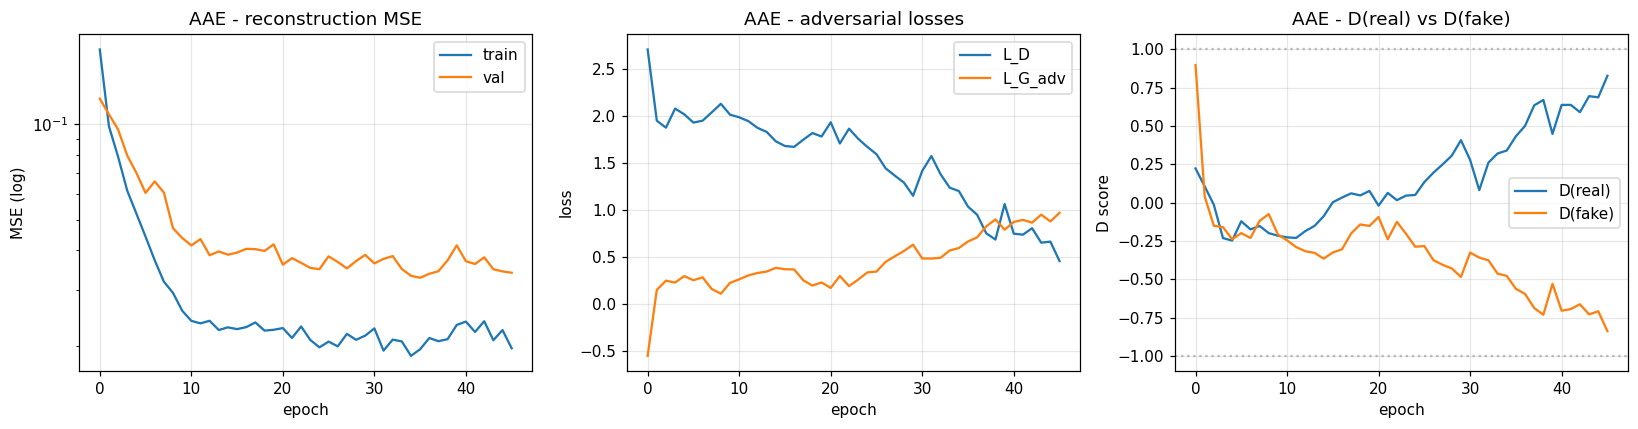

In [10]:
def train_aae(train_loader, val_loader, *, tag="AAE", seed=42):
    """Train G = ConvAE1D and D = Discriminator1D adversarially. Early-stop on val MSE.
    Returns (G, D, history, best_val_mse)."""
    torch.manual_seed(seed); np.random.seed(seed)
    G = ConvAE1D(n_features=n_features, enc_channels=ENC_CHANNELS).to(DEVICE)
    D = Discriminator1D(n_features=n_features, input_len=WINDOW_LEN).to(DEVICE)

    opt_G = torch.optim.Adam(G.parameters(), lr=LR_G_AAE, betas=BETAS_AAE)
    opt_D = torch.optim.Adam(D.parameters(), lr=LR_D_AAE, betas=BETAS_AAE)
    mse   = nn.MSELoss()

    nG = sum(p.numel() for p in G.parameters())
    nD = sum(p.numel() for p in D.parameters())
    print(f"[{tag}]  G params={nG:,}   D params={nD:,}   lambda_adv={LAMBDA_ADV}")

    hist = {"train_mse": [], "val_mse": [],
            "loss_D": [], "loss_G_adv": [],
            "d_real": [], "d_fake": []}
    best_val, best_state, remaining = float("inf"), None, PATIENCE

    for epoch in range(1, EPOCHS + 1):
        G.train(); D.train()
        sums = {k: 0.0 for k in ("mse", "lD", "lGadv", "dreal", "dfake")}
        n_seen = 0
        for (x_real, _) in train_loader:                        # TensorDataset(W,W)
            x_real = x_real.to(DEVICE, non_blocking=True)

            # ---- D step --------------------------------------------------
            opt_D.zero_grad(set_to_none=True)
            with torch.no_grad():
                x_fake_d = G(x_real)
            d_real = D(x_real)
            d_fake = D(x_fake_d)
            loss_D = hinge_loss_D(d_real, d_fake)
            loss_D.backward()
            opt_D.step()

            # ---- G step --------------------------------------------------
            opt_G.zero_grad(set_to_none=True)
            x_fake = G(x_real)
            mse_loss   = mse(x_fake, x_real)
            adv_loss_G = hinge_loss_G(D(x_fake))
            loss_G     = mse_loss + LAMBDA_ADV * adv_loss_G
            loss_G.backward()
            nn.utils.clip_grad_norm_(G.parameters(), GRAD_CLIP)
            opt_G.step()

            bs = x_real.size(0); n_seen += bs
            sums["mse"]   += mse_loss.item()   * bs
            sums["lD"]    += loss_D.item()     * bs
            sums["lGadv"] += adv_loss_G.item() * bs
            sums["dreal"] += d_real.mean().item() * bs
            sums["dfake"] += d_fake.mean().item() * bs

        tr_mse   = sums["mse"]   / n_seen
        tr_lD    = sums["lD"]    / n_seen
        tr_lGadv = sums["lGadv"] / n_seen
        tr_dr    = sums["dreal"] / n_seen
        tr_df    = sums["dfake"] / n_seen

        # ---- val (MSE only) ---------------------------------------------
        G.eval()
        with torch.no_grad():
            tot, n = 0.0, 0
            for (xv, _) in val_loader:
                xv = xv.to(DEVICE, non_blocking=True)
                tot += mse(G(xv), xv).item() * xv.size(0); n += xv.size(0)
            va_mse = tot / max(n, 1)

        hist["train_mse"].append(tr_mse);   hist["val_mse"].append(va_mse)
        hist["loss_D"].append(tr_lD);       hist["loss_G_adv"].append(tr_lGadv)
        hist["d_real"].append(tr_dr);       hist["d_fake"].append(tr_df)

        improved = va_mse < best_val - 1e-6
        if improved:
            best_val = va_mse
            best_state = copy.deepcopy(G.state_dict())
            remaining = PATIENCE
        print(f"  [{tag}] ep {epoch:03d} | MSE tr={tr_mse:.5f} val={va_mse:.5f} | "
              f"L_D={tr_lD:.3f}  L_G_adv={tr_lGadv:+.3f} | "
              f"D(real)={tr_dr:+.2f} D(fake)={tr_df:+.2f}{' *' if improved else ''}")
        if not improved:
            remaining -= 1
            if remaining <= 0:
                print(f"  [{tag}] Early stop at epoch {epoch} (best val MSE {best_val:.6f})")
                break

    G.load_state_dict(best_state)
    return G, D, hist, best_val


aae_G, aae_D, aae_hist, aae_best_val = train_aae(
    recon_train_loader, recon_val_loader, tag="AAE")

torch.save({"G_state": aae_G.state_dict(), "D_state": aae_D.state_dict(),
            "history": aae_hist,
            "config": {"window_len": WINDOW_LEN, "objective": "adversarial reconstruction",
                       "enc_channels": list(ENC_CHANNELS),
                       "batch_size": BATCH_SIZE,
                       "lr_G": LR_G_AAE, "lr_D": LR_D_AAE,
                       "lambda_adv": LAMBDA_ADV, "betas": list(BETAS_AAE),
                       "epochs_run": len(aae_hist["train_mse"]),
                       "best_val_mse": aae_best_val}},
           OUTPUT_DIR / "aae.pt")
print("saved ->", OUTPUT_DIR / "aae.pt")

# --- training diagnostics: MSE curves + L_D/L_G_adv + D(real)/D(fake) ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ax = axes[0]
ax.plot(aae_hist["train_mse"], label="train"); ax.plot(aae_hist["val_mse"], label="val")
ax.set_yscale("log"); ax.set_xlabel("epoch"); ax.set_ylabel("MSE (log)")
ax.set_title("AAE - reconstruction MSE"); ax.legend()

ax = axes[1]
ax.plot(aae_hist["loss_D"],     label="L_D")
ax.plot(aae_hist["loss_G_adv"], label="L_G_adv")
ax.set_xlabel("epoch"); ax.set_ylabel("loss")
ax.set_title("AAE - adversarial losses"); ax.legend()

ax = axes[2]
ax.plot(aae_hist["d_real"], label="D(real)")
ax.plot(aae_hist["d_fake"], label="D(fake)")
ax.axhline(+1, color="grey", linestyle=":", alpha=0.5)
ax.axhline(-1, color="grey", linestyle=":", alpha=0.5)
ax.set_xlabel("epoch"); ax.set_ylabel("D score")
ax.set_title("AAE - D(real) vs D(fake)"); ax.legend()

plt.tight_layout(); plt.show()

### 7.2 Evaluate

Same scoring rule as the recon AE (`mean_MSE` per window), same evaluation helpers, same threshold rule (`mu + 2sigma` of val_normal). The AAE-vs-AE comparison is now strictly head-to-head: only the training objective differs (MSE vs MSE+adv).

val_normal   n= 273  mean=0.03280  p99=0.04268
test_normal  n= 273  mean=0.02629  p99=0.04069
slow         n= 324  mean=0.03290  p99=0.05940

[AAE]  ROC-AUC = 0.5071   PR-AUC = 0.7174
[AAE]  Threshold (val_normal mu+2sigma) = 0.041905

               pred normal | pred anomaly
actual normal        272            1
actual anomaly       185          139

              precision    recall  f1-score   support

      normal      0.595     0.996     0.745       273
     anomaly      0.993     0.429     0.599       324

    accuracy                          0.688       597
   macro avg      0.794     0.713     0.672       597
weighted avg      0.811     0.688     0.666       597



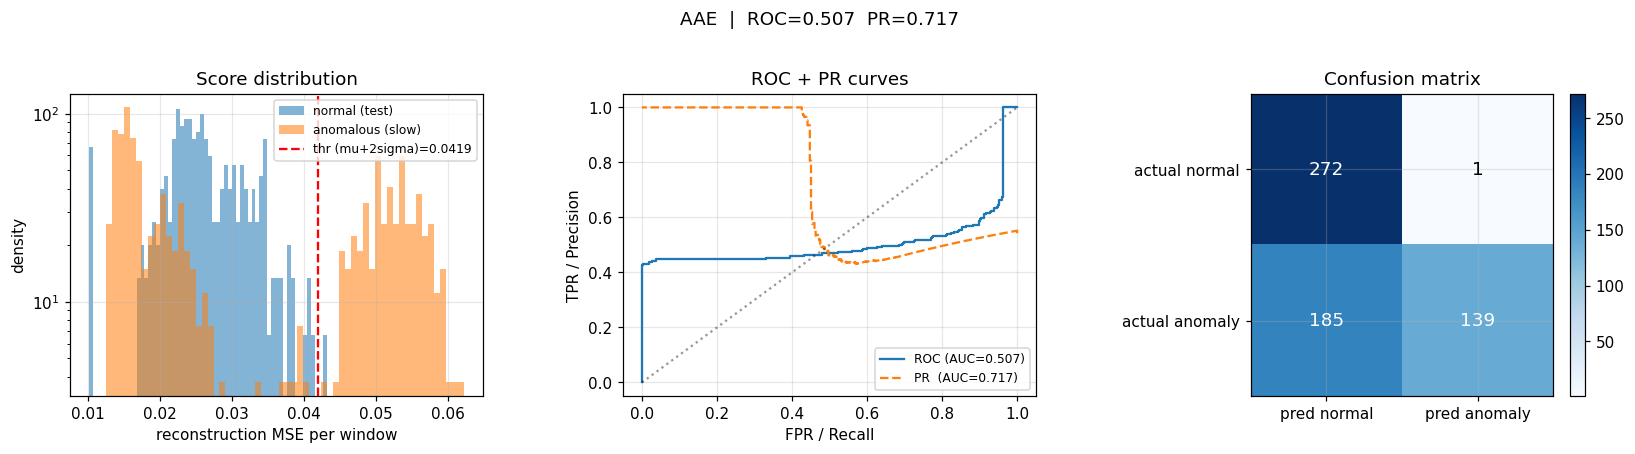

In [11]:
# Reconstruction score = mean MSE between W and G(W). Same scoring as the recon AE.
aae_sv = score_mean_mse(aae_G, W_val,  W_val)
aae_st = score_mean_mse(aae_G, W_test, W_test)
aae_ss = score_mean_mse(aae_G, W_slow, W_slow)

print(f"val_normal   n={aae_sv.size:4d}  mean={aae_sv.mean():.5f}  p99={np.percentile(aae_sv, 99):.5f}")
print(f"test_normal  n={aae_st.size:4d}  mean={aae_st.mean():.5f}  p99={np.percentile(aae_st, 99):.5f}")
print(f"slow         n={aae_ss.size:4d}  mean={aae_ss.mean():.5f}  p99={np.percentile(aae_ss, 99):.5f}")
print()

aae_res = evaluate_scores(aae_sv, aae_st, aae_ss, tag="AAE")
print_headline(aae_res)
plot_diagnostics(aae_res, score_label="reconstruction MSE per window")

## 8. Three-way comparison - AE vs Forecasting AE vs AAE

The full story in one table. Two independent ablations:

- **Recon AE -> Forecasting AE**: changes the *objective* (reconstruct vs predict-next).
- **Recon AE -> AAE**: changes the *training regularization* (MSE only vs MSE + adversarial).

Threshold-free metrics (ROC-AUC, PR-AUC) are the primary numbers.

                 model |  ROC-AUC |  PR-AUC | thr (mu+2sig) |     P     R    F1 |  TP  FP  TN  FN
----------------------------------------------------------------------------------------------------
     Reconstruction AE |   0.4659 |  0.6889 |       0.03360 | 1.000 0.225 0.368 |  73   0 273 251
        Forecasting AE |   0.6512 |  0.7788 |       0.06833 | 0.913 0.454 0.606 | 147  14 259 177
                   AAE |   0.5071 |  0.7174 |       0.04191 | 0.993 0.429 0.599 | 139   1 272 185


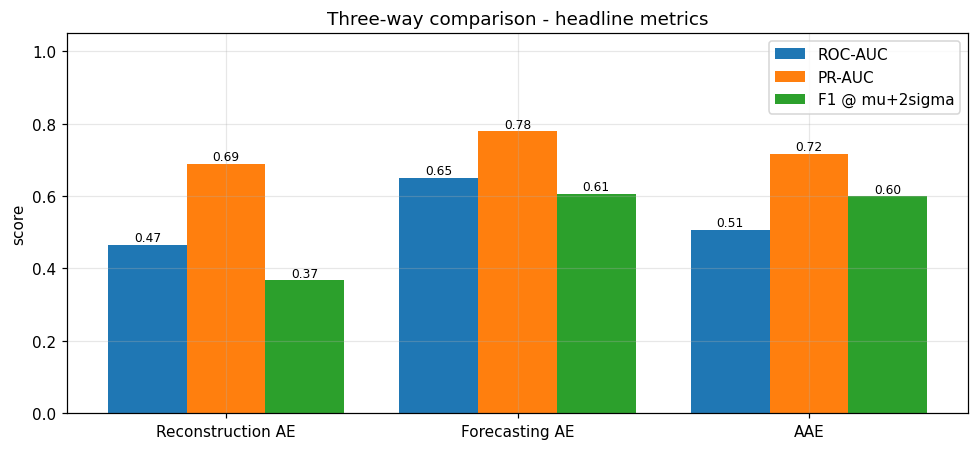


saved -> c:\Users\siava\Desktop\4th_Semester\ML-App\project-AM01\github_version\ML_APP_Anomaly_Detection\outputs\ae_compare\unsupervised\compare_3way.json

ROC-AUC winner: Forecasting AE  (0.651)
PR-AUC  winner: Forecasting AE  (0.779)

AAE vs Reconstruction AE (head-to-head):
  Delta ROC-AUC = +0.0412   Delta PR-AUC = +0.0285
  --> Adversarial regularization HELPS ROC-AUC.
  --> Adversarial regularization HELPS PR-AUC.


In [12]:
results_3way = [recon_res, fc_res, aae_res]

# ---------------- side-by-side text table ------------------------------
print(f"{'model':>22s} | {'ROC-AUC':>8s} | {'PR-AUC':>7s} | "
      f"{'thr (mu+2sig)':>13s} | {'P':>5s} {'R':>5s} {'F1':>5s} | "
      f"{'TP':>3s} {'FP':>3s} {'TN':>3s} {'FN':>3s}")
print("-" * 100)
for r in results_3way:
    op = r["operating_points"]["mu+2sigma"]
    print(f"{r['tag']:>22s} | {r['roc_auc']:8.4f} | {r['pr_auc']:7.4f} | "
          f"{r['threshold']:13.5f} | {op['P']:5.3f} {op['R']:5.3f} {op['F1']:5.3f} | "
          f"{op['tp']:3d} {op['fp']:3d} {op['tn']:3d} {op['fn']:3d}")

# ---------------- bar chart: ROC-AUC, PR-AUC, F1 -----------------------
labels = [r["tag"] for r in results_3way]
roc = [r["roc_auc"] for r in results_3way]
pr  = [r["pr_auc"]  for r in results_3way]
f1  = [r["operating_points"]["mu+2sigma"]["F1"] for r in results_3way]

x = np.arange(len(labels)); w = 0.27
fig, ax = plt.subplots(figsize=(9, 4.2))
ax.bar(x - w, roc, width=w, label="ROC-AUC")
ax.bar(x,     pr,  width=w, label="PR-AUC")
ax.bar(x + w, f1,  width=w, label="F1 @ mu+2sigma")
for i, v in enumerate(roc): ax.text(i - w, v + 0.01, f"{v:.2f}", ha="center", fontsize=8)
for i, v in enumerate(pr):  ax.text(i,     v + 0.01, f"{v:.2f}", ha="center", fontsize=8)
for i, v in enumerate(f1):  ax.text(i + w, v + 0.01, f"{v:.2f}", ha="center", fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylim(0.0, 1.05); ax.set_ylabel("score")
ax.set_title("Three-way comparison - headline metrics")
ax.legend(); plt.tight_layout(); plt.show()

# ---------------- save 3-way comparison JSON ---------------------------
summary_3way = {
    "config": {
        "window_len": WINDOW_LEN, "forecast_half": FORECAST_HALF,
        "enc_channels": list(ENC_CHANNELS), "batch_size": BATCH_SIZE,
        "epochs_cap": EPOCHS, "patience": PATIENCE,
        "ae_lr": LEARNING_RATE,
        "aae_lr_G": LR_G_AAE, "aae_lr_D": LR_D_AAE,
        "aae_lambda_adv": LAMBDA_ADV, "aae_betas": list(BETAS_AAE),
        "data": "KukaNormal (action dropped, 85 features)",
        "n_test_normal": int(recon_st.size), "n_test_anomaly": int(recon_ss.size),
    },
    "models": {
        r["tag"]: {
            "roc_auc": r["roc_auc"],
            "pr_auc":  r["pr_auc"],
            "operating_points": r["operating_points"],
        } for r in results_3way
    },
}
with open(OUTPUT_DIR / "compare_3way.json", "w", encoding="utf-8") as f:
    json.dump(summary_3way, f, indent=2, default=float)
print("\nsaved ->", OUTPUT_DIR / "compare_3way.json")

# ---------------- one-line takeaways -----------------------------------
roc_win = max(results_3way, key=lambda r: r["roc_auc"])
pr_win  = max(results_3way, key=lambda r: r["pr_auc"])
print(f"\nROC-AUC winner: {roc_win['tag']}  ({roc_win['roc_auc']:.3f})")
print(f"PR-AUC  winner: {pr_win['tag']}  ({pr_win['pr_auc']:.3f})")

# Head-to-head: recon AE vs AAE (the actual AAE question we set out to answer)
delta_roc = aae_res["roc_auc"] - recon_res["roc_auc"]
delta_pr  = aae_res["pr_auc"]  - recon_res["pr_auc"]
print(f"\nAAE vs Reconstruction AE (head-to-head):")
print(f"  Delta ROC-AUC = {delta_roc:+.4f}   Delta PR-AUC = {delta_pr:+.4f}")
print(f"  --> Adversarial regularization {'HELPS' if delta_roc > 0 else 'does NOT help'} ROC-AUC.")
print(f"  --> Adversarial regularization {'HELPS' if delta_pr  > 0 else 'does NOT help'} PR-AUC.")

## 9. AAE v2 sweep - adversarial hyperparameters

This section keeps the comparison honest:

- same `ConvAE1D` generator as the reconstruction AE and AAE v1
- same `Discriminator1D` architecture as AAE v1
- same inference/anomaly score: reconstruction `mean_MSE` per window

Only the adversarial training recipe changes: `lambda_adv`, discriminator learning rate, and the generator adversarial loss variant.

In [13]:
# --- AAE v2 sweep config ------------------------------------------------
# All variants use the same generator/discriminator architecture and MSE inference score.
AAE_V2_SWEEP_CONFIGS = [
    {"name": "lam001_d1e4_linear", "lambda_adv": 0.001, "lr_G": 1e-3, "lr_D": 1e-4, "g_loss": "linear"},
    {"name": "lam003_d1e4_linear", "lambda_adv": 0.003, "lr_G": 1e-3, "lr_D": 1e-4, "g_loss": "linear"},
    {"name": "lam001_d2e4_linear", "lambda_adv": 0.001, "lr_G": 1e-3, "lr_D": 2e-4, "g_loss": "linear"},
    {"name": "lam003_d2e4_linear", "lambda_adv": 0.003, "lr_G": 1e-3, "lr_D": 2e-4, "g_loss": "linear"},
    {"name": "lam001_d4e4_linear", "lambda_adv": 0.001, "lr_G": 1e-3, "lr_D": 4e-4, "g_loss": "linear"},
    {"name": "lam003_d4e4_linear", "lambda_adv": 0.003, "lr_G": 1e-3, "lr_D": 4e-4, "g_loss": "linear"},
    {"name": "lam001_d2e4_hinge",  "lambda_adv": 0.001, "lr_G": 1e-3, "lr_D": 2e-4, "g_loss": "hinge"},
    {"name": "lam003_d2e4_hinge",  "lambda_adv": 0.003, "lr_G": 1e-3, "lr_D": 2e-4, "g_loss": "hinge"},
]

AAE_V2_SWEEP_EPOCHS = EPOCHS
AAE_V2_SWEEP_PATIENCE = PATIENCE
AAE_V2_BETAS = BETAS_AAE


def generator_adv_loss_v2(d_fake, mode):
    if mode == "linear":
        return -d_fake.mean()                  # same as AAE v1 / lab notebook
    if mode == "hinge":
        return F.relu(1.0 - d_fake).mean()     # slide-style generator hinge
    raise ValueError(f"unknown generator loss mode: {mode}")


def compact_result(res):
    return {
        "tag": res["tag"],
        "roc_auc": res["roc_auc"],
        "pr_auc": res["pr_auc"],
        "threshold": res["threshold"],
        "operating_points": res["operating_points"],
    }


def train_aae_v2_variant(cfg, *, seed=42):
    """Train one AAE v2 candidate. Returns G, D, history, best val MSE."""
    torch.manual_seed(seed); np.random.seed(seed)
    G = ConvAE1D(n_features=n_features, enc_channels=ENC_CHANNELS).to(DEVICE)
    D = Discriminator1D(n_features=n_features, input_len=WINDOW_LEN).to(DEVICE)

    opt_G = torch.optim.Adam(G.parameters(), lr=cfg["lr_G"], betas=AAE_V2_BETAS)
    opt_D = torch.optim.Adam(D.parameters(), lr=cfg["lr_D"], betas=AAE_V2_BETAS)
    mse = nn.MSELoss()

    hist = {"train_mse": [], "val_mse": [], "loss_D": [], "loss_G_adv": [],
            "d_real": [], "d_fake": []}
    best_val, best_state, remaining = float("inf"), None, AAE_V2_SWEEP_PATIENCE
    tag = cfg["name"]
    print(f"\n[AAE v2:{tag}] lambda={cfg['lambda_adv']} lr_G={cfg['lr_G']:g} "
          f"lr_D={cfg['lr_D']:g} g_loss={cfg['g_loss']}")

    for epoch in range(1, AAE_V2_SWEEP_EPOCHS + 1):
        G.train(); D.train()
        sums = {k: 0.0 for k in ("mse", "lD", "lGadv", "dreal", "dfake")}
        n_seen = 0

        for (x_real, _) in recon_train_loader:
            x_real = x_real.to(DEVICE, non_blocking=True)

            # D step: real normal windows vs detached reconstructions.
            opt_D.zero_grad(set_to_none=True)
            with torch.no_grad():
                x_fake_d = G(x_real)
            d_real = D(x_real)
            d_fake = D(x_fake_d)
            loss_D = hinge_loss_D(d_real, d_fake)
            loss_D.backward()
            opt_D.step()

            # G step: reconstruction MSE remains dominant.
            opt_G.zero_grad(set_to_none=True)
            x_fake = G(x_real)
            mse_loss = mse(x_fake, x_real)
            adv_loss_G = generator_adv_loss_v2(D(x_fake), cfg["g_loss"])
            loss_G = mse_loss + cfg["lambda_adv"] * adv_loss_G
            loss_G.backward()
            nn.utils.clip_grad_norm_(G.parameters(), GRAD_CLIP)
            opt_G.step()

            bs = x_real.size(0); n_seen += bs
            sums["mse"] += mse_loss.item() * bs
            sums["lD"] += loss_D.item() * bs
            sums["lGadv"] += adv_loss_G.item() * bs
            sums["dreal"] += d_real.mean().item() * bs
            sums["dfake"] += d_fake.mean().item() * bs

        tr_mse = sums["mse"] / n_seen
        tr_lD = sums["lD"] / n_seen
        tr_lGadv = sums["lGadv"] / n_seen
        tr_dr = sums["dreal"] / n_seen
        tr_df = sums["dfake"] / n_seen

        G.eval()
        with torch.no_grad():
            tot, n = 0.0, 0
            for (xv, _) in recon_val_loader:
                xv = xv.to(DEVICE, non_blocking=True)
                tot += mse(G(xv), xv).item() * xv.size(0); n += xv.size(0)
            va_mse = tot / max(n, 1)

        hist["train_mse"].append(tr_mse); hist["val_mse"].append(va_mse)
        hist["loss_D"].append(tr_lD); hist["loss_G_adv"].append(tr_lGadv)
        hist["d_real"].append(tr_dr); hist["d_fake"].append(tr_df)

        improved = va_mse < best_val - 1e-6
        if improved:
            best_val = va_mse
            best_state = {"G": copy.deepcopy(G.state_dict()), "D": copy.deepcopy(D.state_dict())}
            remaining = AAE_V2_SWEEP_PATIENCE
        else:
            remaining -= 1

        print(f"  ep {epoch:03d} | MSE tr={tr_mse:.5f} val={va_mse:.5f} | "
              f"L_D={tr_lD:.3f} L_G_adv={tr_lGadv:+.3f} | "
              f"D(real)={tr_dr:+.2f} D(fake)={tr_df:+.2f}{' *' if improved else ''}")
        if remaining <= 0:
            print(f"  early stop at epoch {epoch} (best val MSE {best_val:.6f})")
            break

    G.load_state_dict(best_state["G"])
    D.load_state_dict(best_state["D"])
    return G, D, hist, best_val


def evaluate_aae_v2_variant(G, cfg):
    sv = score_mean_mse(G, W_val, W_val)
    st = score_mean_mse(G, W_test, W_test)
    ss = score_mean_mse(G, W_slow, W_slow)
    res = evaluate_scores(sv, st, ss, tag=f"AAE v2 {cfg['name']}")
    print(f"  scores: val_mean={sv.mean():.5f} test_mean={st.mean():.5f} slow_mean={ss.mean():.5f} | "
          f"ROC={res['roc_auc']:.4f} PR={res['pr_auc']:.4f} "
          f"F1={res['operating_points']['mu+2sigma']['F1']:.4f}")
    return res, {"sv": sv, "st": st, "ss": ss}


print(f"AAE v2 sweep configs: {len(AAE_V2_SWEEP_CONFIGS)}")

AAE v2 sweep configs: 8


### 9.1 Run the sweep

This can take several minutes on GPU. Each candidate uses the same reconstruction-MSE scoring rule as the AE and AAE v1.

In [14]:
aae_v2_runs = []

for cfg in AAE_V2_SWEEP_CONFIGS:
    G, D, hist, best_val = train_aae_v2_variant(cfg, seed=42)
    res, scores = evaluate_aae_v2_variant(G, cfg)

    ckpt_path = OUTPUT_DIR / f"aae_v2_{cfg['name']}.pt"
    torch.save({
        "G_state": G.state_dict(),
        "D_state": D.state_dict(),
        "history": hist,
        "config": {**cfg, "epochs_run": len(hist["train_mse"]), "best_val_mse": best_val},
        "metrics": compact_result(res),
    }, ckpt_path)

    aae_v2_runs.append({
        "cfg": cfg,
        "G": G,
        "D": D,
        "history": hist,
        "best_val": best_val,
        "result": res,
        "scores": scores,
        "checkpoint": str(ckpt_path),
    })
    print("saved ->", ckpt_path)

# Choose the headline v2 using validation-normal MSE only.
# This keeps test labels out of model/hyperparameter selection.
best_run = min(aae_v2_runs, key=lambda r: r["best_val"])
aae_v2_best_res = best_run["result"]
aae_v2_best_cfg = best_run["cfg"]
aae_v2_best_G = best_run["G"]
aae_v2_best_D = best_run["D"]

torch.save({
    "G_state": aae_v2_best_G.state_dict(),
    "D_state": aae_v2_best_D.state_dict(),
    "history": best_run["history"],
    "config": {**aae_v2_best_cfg, "best_val_mse": best_run["best_val"]},
    "metrics": compact_result(aae_v2_best_res),
}, OUTPUT_DIR / "aae_v2_best.pt")

print("\nBest AAE v2 by validation-normal MSE:")
print(aae_v2_best_cfg)
print(f"best_val_mse={best_run['best_val']:.6f} | "
      f"test ROC={aae_v2_best_res['roc_auc']:.4f} test PR={aae_v2_best_res['pr_auc']:.4f} "
      f"F1={aae_v2_best_res['operating_points']['mu+2sigma']['F1']:.4f}")
print("saved ->", OUTPUT_DIR / "aae_v2_best.pt")


[AAE v2:lam001_d1e4_linear] lambda=0.001 lr_G=0.001 lr_D=0.0001 g_loss=linear
  ep 001 | MSE tr=0.15239 val=0.10434 | L_D=1.243 L_G_adv=+0.711 | D(real)=+0.36 D(fake)=-0.47 *
  ep 002 | MSE tr=0.07597 val=0.08060 | L_D=0.964 L_G_adv=+0.795 | D(real)=+0.44 D(fake)=-0.65 *
  ep 003 | MSE tr=0.05605 val=0.06792 | L_D=0.793 L_G_adv=+0.866 | D(real)=+0.51 D(fake)=-0.77 *
  ep 004 | MSE tr=0.04462 val=0.06278 | L_D=0.492 L_G_adv=+0.991 | D(real)=+0.79 D(fake)=-0.88 *
  ep 005 | MSE tr=0.03506 val=0.05488 | L_D=0.442 L_G_adv=+1.027 | D(real)=+0.83 D(fake)=-0.92 *
  ep 006 | MSE tr=0.02921 val=0.04645 | L_D=0.650 L_G_adv=+0.936 | D(real)=+0.65 D(fake)=-0.81 *
  ep 007 | MSE tr=0.02671 val=0.05339 | L_D=0.434 L_G_adv=+1.051 | D(real)=+0.87 D(fake)=-0.96
  ep 008 | MSE tr=0.02661 val=0.04335 | L_D=0.156 L_G_adv=+1.280 | D(real)=+1.18 D(fake)=-1.20 *
  ep 009 | MSE tr=0.02491 val=0.04212 | L_D=0.093 L_G_adv=+1.374 | D(real)=+1.32 D(fake)=-1.28 *
  ep 010 | MSE tr=0.02452 val=0.04035 | L_D=0.113 

### 9.2 Sweep results and final AE-vs-AAE comparison

                 variant |   val MSE |  lambda |    lr_D |  G loss | test ROC test PR     F1 |     P     R
----------------------------------------------------------------------------------------------------------------
      lam001_d1e4_linear |   0.02530 |   0.001 | 1.0e-04 |  linear |    0.463   0.689  0.210 | 1.000 0.117
      lam001_d4e4_linear |   0.02803 |   0.001 | 4.0e-04 |  linear |    0.490   0.711  0.461 | 1.000 0.299
      lam003_d2e4_linear |   0.02825 |   0.003 | 2.0e-04 |  linear |    0.477   0.702  0.580 | 0.897 0.429
      lam001_d2e4_linear |   0.02866 |   0.001 | 2.0e-04 |  linear |    0.434   0.586  0.404 | 0.761 0.275
       lam001_d2e4_hinge |   0.02866 |   0.001 | 2.0e-04 |   hinge |    0.434   0.586  0.404 | 0.761 0.275
      lam003_d4e4_linear |   0.03007 |   0.003 | 4.0e-04 |  linear |    0.481   0.705  0.368 | 1.000 0.225
      lam003_d1e4_linear |   0.03086 |   0.003 | 1.0e-04 |  linear |    0.503   0.703  0.424 | 0.967 0.272
       lam003_d2e4_hinge |   0.

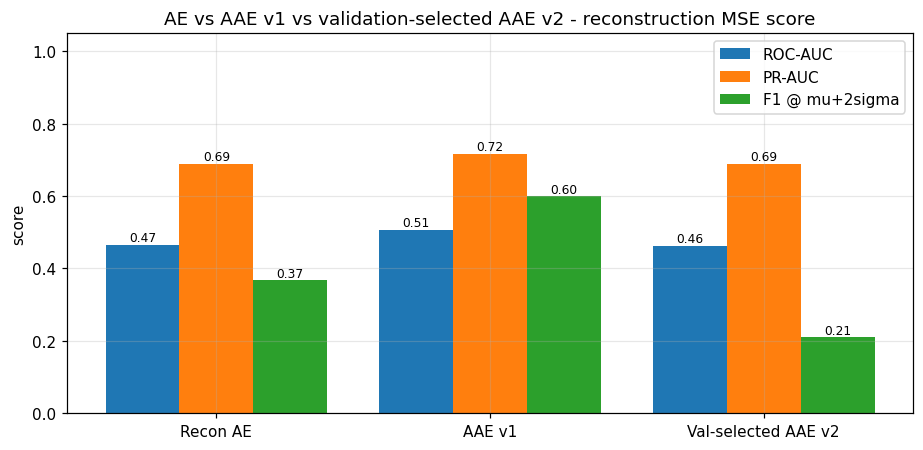

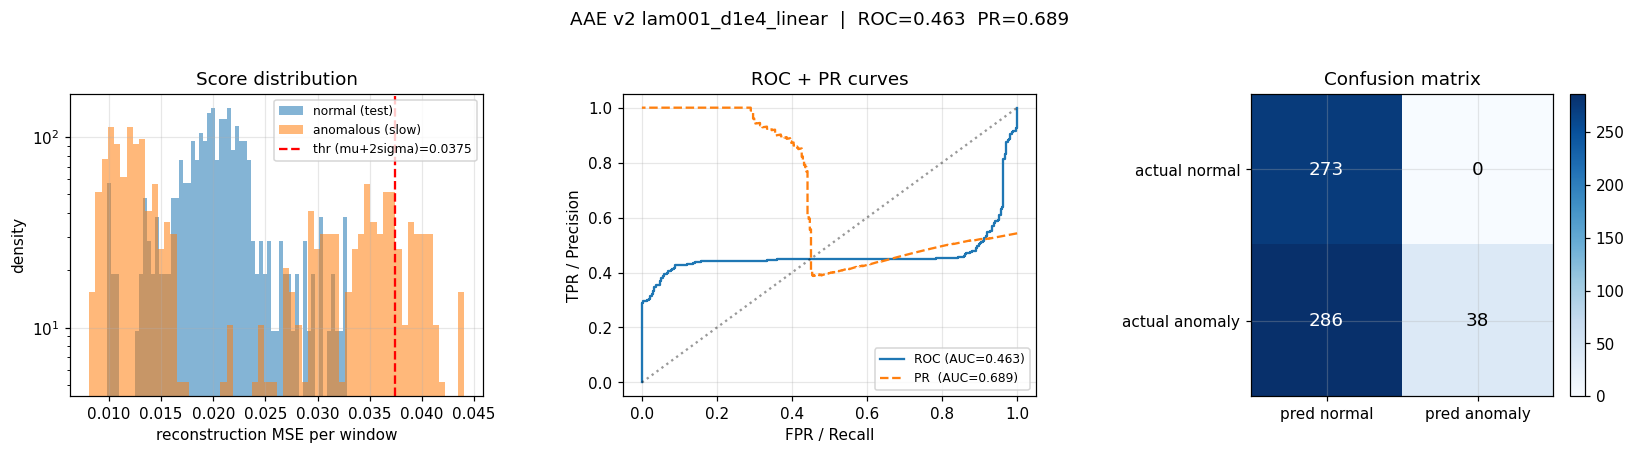


saved -> c:\Users\siava\Desktop\4th_Semester\ML-App\project-AM01\github_version\ML_APP_Anomaly_Detection\outputs\ae_compare\unsupervised\compare_aae_v2_sweep.json

Validation-selected AAE v2 vs AAE v1:
  Delta ROC-AUC = -0.0437
  Delta PR-AUC  = -0.0287
  Delta F1      = -0.3892


In [15]:
# ---------------- all sweep candidates ---------------------------------
print(f"{'variant':>24s} | {'val MSE':>9s} | {'lambda':>7s} | {'lr_D':>7s} | {'G loss':>7s} | "
      f"{'test ROC':>8s} {'test PR':>7s} {'F1':>6s} | {'P':>5s} {'R':>5s}")
print("-" * 112)
for run in sorted(aae_v2_runs, key=lambda r: r["best_val"]):
    cfg = run["cfg"]; res = run["result"]
    op = res["operating_points"]["mu+2sigma"]
    print(f"{cfg['name']:>24s} | {run['best_val']:9.5f} | {cfg['lambda_adv']:7.3g} | "
          f"{cfg['lr_D']:7.1e} | {cfg['g_loss']:>7s} | "
          f"{res['roc_auc']:8.3f} {res['pr_auc']:7.3f} {op['F1']:6.3f} | {op['P']:5.3f} {op['R']:5.3f}")

# ---------------- compare AE, AAE v1, best AAE v2 ----------------------
results_aae_sweep = [recon_res, aae_res, aae_v2_best_res]

print("\nValidation-selected AAE v2 vs baselines")
print(f"{'model':>28s} | {'ROC-AUC':>8s} | {'PR-AUC':>7s} | "
      f"{'thr (mu+2sig)':>13s} | {'P':>5s} {'R':>5s} {'F1':>5s} | "
      f"{'TP':>3s} {'FP':>3s} {'TN':>3s} {'FN':>3s}")
print("-" * 108)
for r in results_aae_sweep:
    op = r["operating_points"]["mu+2sigma"]
    print(f"{r['tag']:>28s} | {r['roc_auc']:8.4f} | {r['pr_auc']:7.4f} | "
          f"{r['threshold']:13.5f} | {op['P']:5.3f} {op['R']:5.3f} {op['F1']:5.3f} | "
          f"{op['tp']:3d} {op['fp']:3d} {op['tn']:3d} {op['fn']:3d}")

labels = ["Recon AE", "AAE v1", "Val-selected AAE v2"]
roc = [r["roc_auc"] for r in results_aae_sweep]
pr = [r["pr_auc"] for r in results_aae_sweep]
f1 = [r["operating_points"]["mu+2sigma"]["F1"] for r in results_aae_sweep]

x = np.arange(len(labels)); w = 0.27
fig, ax = plt.subplots(figsize=(8.5, 4.2))
ax.bar(x - w, roc, width=w, label="ROC-AUC")
ax.bar(x, pr, width=w, label="PR-AUC")
ax.bar(x + w, f1, width=w, label="F1 @ mu+2sigma")
for i, v in enumerate(roc): ax.text(i - w, v + 0.01, f"{v:.2f}", ha="center", fontsize=8)
for i, v in enumerate(pr): ax.text(i, v + 0.01, f"{v:.2f}", ha="center", fontsize=8)
for i, v in enumerate(f1): ax.text(i + w, v + 0.01, f"{v:.2f}", ha="center", fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylim(0.0, 1.05); ax.set_ylabel("score")
ax.set_title("AE vs AAE v1 vs validation-selected AAE v2 - reconstruction MSE score")
ax.legend(); plt.tight_layout(); plt.show()

plot_diagnostics(aae_v2_best_res, score_label="reconstruction MSE per window")

# ---------------- save sweep summary -----------------------------------
summary_aae_v2_sweep = {
    "selection": "best validation-normal MSE; test labels are not used for model selection",
    "fixed": {
        "generator": "ConvAE1D unchanged",
        "discriminator": "Discriminator1D unchanged",
        "inference_score": "reconstruction mean_MSE per window",
        "epochs_cap": AAE_V2_SWEEP_EPOCHS,
        "patience": AAE_V2_SWEEP_PATIENCE,
        "betas": list(AAE_V2_BETAS),
    },
    "sweep": [
        {
            "config": run["cfg"],
            "best_val_mse": run["best_val"],
            "checkpoint": run["checkpoint"],
            "metrics": compact_result(run["result"]),
        } for run in aae_v2_runs
    ],
    "best": {
        "config": aae_v2_best_cfg,
        "metrics": compact_result(aae_v2_best_res),
    },
    "baselines": {
        "Reconstruction AE": compact_result(recon_res),
        "AAE v1": compact_result(aae_res),
    },
}
with open(OUTPUT_DIR / "compare_aae_v2_sweep.json", "w", encoding="utf-8") as f:
    json.dump(summary_aae_v2_sweep, f, indent=2, default=float)
print("\nsaved ->", OUTPUT_DIR / "compare_aae_v2_sweep.json")

print("\nValidation-selected AAE v2 vs AAE v1:")
print(f"  Delta ROC-AUC = {aae_v2_best_res['roc_auc'] - aae_res['roc_auc']:+.4f}")
print(f"  Delta PR-AUC  = {aae_v2_best_res['pr_auc'] - aae_res['pr_auc']:+.4f}")
print(f"  Delta F1      = {aae_v2_best_res['operating_points']['mu+2sigma']['F1'] - aae_res['operating_points']['mu+2sigma']['F1']:+.4f}")

## 10. Forecasting AAE - adversarial forecasting objective

This is a separate ablation from reconstruction AAE:

- Forecasting AE: input = first 64 timesteps, target = next 64 timesteps.
- Forecasting AAE: same forecasting generator, plus a discriminator that judges real future windows vs generated future windows.
- Inference score stays forecast `mean_MSE`, exactly like Forecasting AE.

So this section asks: does adversarial regularization help the forecasting objective?

[Forecasting AAE] G params=48,277   D params=53,473   lambda_adv=0.01
  [Forecasting AAE] ep 001 | MSE tr=0.17102 val=0.11538 | L_D=2.327 L_G_adv=-0.289 | D(real)=+0.30 D(fake)=+0.61 *
  [Forecasting AAE] ep 002 | MSE tr=0.10038 val=0.10347 | L_D=2.323 L_G_adv=-0.322 | D(real)=+0.19 D(fake)=+0.50 *
  [Forecasting AAE] ep 003 | MSE tr=0.07877 val=0.09050 | L_D=2.218 L_G_adv=-0.154 | D(real)=+0.04 D(fake)=+0.26 *
  [Forecasting AAE] ep 004 | MSE tr=0.06276 val=0.08086 | L_D=2.042 L_G_adv=+0.103 | D(real)=-0.08 D(fake)=-0.05 *
  [Forecasting AAE] ep 005 | MSE tr=0.05494 val=0.07266 | L_D=1.819 L_G_adv=+0.345 | D(real)=-0.12 D(fake)=-0.30 *
  [Forecasting AAE] ep 006 | MSE tr=0.04897 val=0.06687 | L_D=1.816 L_G_adv=+0.426 | D(real)=-0.19 D(fake)=-0.38 *
  [Forecasting AAE] ep 007 | MSE tr=0.04669 val=0.06222 | L_D=1.635 L_G_adv=+0.555 | D(real)=-0.14 D(fake)=-0.52 *
  [Forecasting AAE] ep 008 | MSE tr=0.04680 val=0.06647 | L_D=1.482 L_G_adv=+0.615 | D(real)=-0.02 D(fake)=-0.55
  [Forecasti

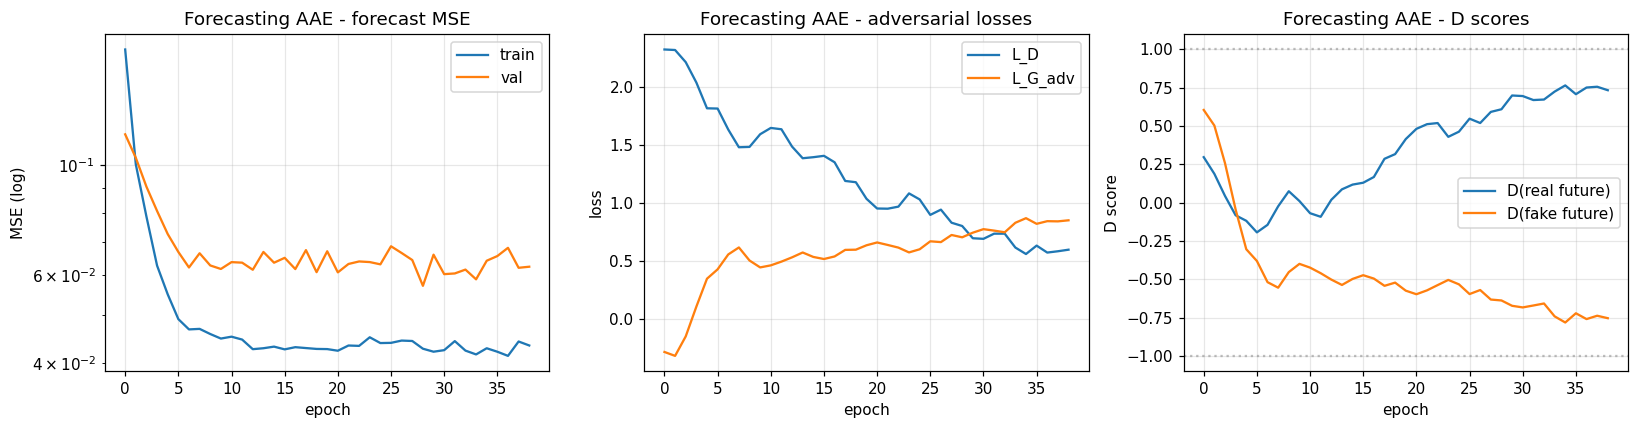

In [16]:
# --- Forecasting AAE hyperparameters -----------------------------------
# Same generator architecture as Forecasting AE; discriminator sees 64-step future windows.
LR_G_FAAE = 1e-3
LR_D_FAAE = 1e-4
LAMBDA_ADV_FAAE = 0.01
BETAS_FAAE = (0.5, 0.999)


def train_forecast_aae(train_loader, val_loader, *, tag="Forecasting AAE", seed=42):
    """Train G(first half) -> next half, with D judging real vs generated future windows."""
    torch.manual_seed(seed); np.random.seed(seed)
    G = ConvAE1D(n_features=n_features, enc_channels=ENC_CHANNELS).to(DEVICE)
    D = Discriminator1D(n_features=n_features, input_len=FORECAST_HALF).to(DEVICE)

    opt_G = torch.optim.Adam(G.parameters(), lr=LR_G_FAAE, betas=BETAS_FAAE)
    opt_D = torch.optim.Adam(D.parameters(), lr=LR_D_FAAE, betas=BETAS_FAAE)
    mse = nn.MSELoss()

    nG = sum(p.numel() for p in G.parameters())
    nD = sum(p.numel() for p in D.parameters())
    print(f"[{tag}] G params={nG:,}   D params={nD:,}   lambda_adv={LAMBDA_ADV_FAAE}")

    hist = {"train_mse": [], "val_mse": [], "loss_D": [], "loss_G_adv": [],
            "d_real": [], "d_fake": []}
    best_val, best_state, remaining = float("inf"), None, PATIENCE

    for epoch in range(1, EPOCHS + 1):
        G.train(); D.train()
        sums = {k: 0.0 for k in ("mse", "lD", "lGadv", "dreal", "dfake")}
        n_seen = 0

        for x_past, x_future in train_loader:
            x_past = x_past.to(DEVICE, non_blocking=True)
            x_future = x_future.to(DEVICE, non_blocking=True)

            # D step: real future windows vs generated future windows.
            opt_D.zero_grad(set_to_none=True)
            with torch.no_grad():
                x_fake_d = G(x_past)
            d_real = D(x_future)
            d_fake = D(x_fake_d)
            loss_D = hinge_loss_D(d_real, d_fake)
            loss_D.backward()
            opt_D.step()

            # G step: forecast MSE + adversarial future-window realism.
            opt_G.zero_grad(set_to_none=True)
            x_fake = G(x_past)
            mse_loss = mse(x_fake, x_future)
            adv_loss_G = hinge_loss_G(D(x_fake))
            loss_G = mse_loss + LAMBDA_ADV_FAAE * adv_loss_G
            loss_G.backward()
            nn.utils.clip_grad_norm_(G.parameters(), GRAD_CLIP)
            opt_G.step()

            bs = x_past.size(0); n_seen += bs
            sums["mse"] += mse_loss.item() * bs
            sums["lD"] += loss_D.item() * bs
            sums["lGadv"] += adv_loss_G.item() * bs
            sums["dreal"] += d_real.mean().item() * bs
            sums["dfake"] += d_fake.mean().item() * bs

        tr_mse = sums["mse"] / n_seen
        tr_lD = sums["lD"] / n_seen
        tr_lGadv = sums["lGadv"] / n_seen
        tr_dr = sums["dreal"] / n_seen
        tr_df = sums["dfake"] / n_seen

        G.eval()
        with torch.no_grad():
            tot, n = 0.0, 0
            for xv_past, xv_future in val_loader:
                xv_past = xv_past.to(DEVICE, non_blocking=True)
                xv_future = xv_future.to(DEVICE, non_blocking=True)
                tot += mse(G(xv_past), xv_future).item() * xv_past.size(0)
                n += xv_past.size(0)
            va_mse = tot / max(n, 1)

        hist["train_mse"].append(tr_mse); hist["val_mse"].append(va_mse)
        hist["loss_D"].append(tr_lD); hist["loss_G_adv"].append(tr_lGadv)
        hist["d_real"].append(tr_dr); hist["d_fake"].append(tr_df)

        improved = va_mse < best_val - 1e-6
        if improved:
            best_val = va_mse
            best_state = {"G": copy.deepcopy(G.state_dict()), "D": copy.deepcopy(D.state_dict())}
            remaining = PATIENCE
        print(f"  [{tag}] ep {epoch:03d} | MSE tr={tr_mse:.5f} val={va_mse:.5f} | "
              f"L_D={tr_lD:.3f} L_G_adv={tr_lGadv:+.3f} | "
              f"D(real)={tr_dr:+.2f} D(fake)={tr_df:+.2f}{' *' if improved else ''}")

        if not improved:
            remaining -= 1
            if remaining <= 0:
                print(f"  [{tag}] Early stop at epoch {epoch} (best val MSE {best_val:.6f})")
                break

    G.load_state_dict(best_state["G"])
    D.load_state_dict(best_state["D"])
    return G, D, hist, best_val


fc_aae_G, fc_aae_D, fc_aae_hist, fc_aae_best_val = train_forecast_aae(
    forecast_train_loader, forecast_val_loader, tag="Forecasting AAE")

torch.save({"G_state": fc_aae_G.state_dict(), "D_state": fc_aae_D.state_dict(),
            "history": fc_aae_hist,
            "config": {"window_len": WINDOW_LEN,
                       "forecast_half": FORECAST_HALF,
                       "objective": "adversarial forecasting",
                       "enc_channels": list(ENC_CHANNELS),
                       "batch_size": BATCH_SIZE,
                       "lr_G": LR_G_FAAE, "lr_D": LR_D_FAAE,
                       "lambda_adv": LAMBDA_ADV_FAAE,
                       "betas": list(BETAS_FAAE),
                       "epochs_run": len(fc_aae_hist["train_mse"]),
                       "best_val_mse": fc_aae_best_val}},
           OUTPUT_DIR / "forecast_aae.pt")
print("saved ->", OUTPUT_DIR / "forecast_aae.pt")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
ax = axes[0]
ax.plot(fc_aae_hist["train_mse"], label="train"); ax.plot(fc_aae_hist["val_mse"], label="val")
ax.set_yscale("log"); ax.set_xlabel("epoch"); ax.set_ylabel("MSE (log)")
ax.set_title("Forecasting AAE - forecast MSE"); ax.legend()

ax = axes[1]
ax.plot(fc_aae_hist["loss_D"], label="L_D")
ax.plot(fc_aae_hist["loss_G_adv"], label="L_G_adv")
ax.set_xlabel("epoch"); ax.set_ylabel("loss")
ax.set_title("Forecasting AAE - adversarial losses"); ax.legend()

ax = axes[2]
ax.plot(fc_aae_hist["d_real"], label="D(real future)")
ax.plot(fc_aae_hist["d_fake"], label="D(fake future)")
ax.axhline(+1, color="grey", linestyle=":", alpha=0.5)
ax.axhline(-1, color="grey", linestyle=":", alpha=0.5)
ax.set_xlabel("epoch"); ax.set_ylabel("D score")
ax.set_title("Forecasting AAE - D scores"); ax.legend()

plt.tight_layout(); plt.show()

### 10A. Windowing strategy experiment

This experiment is a model-selection step for the window configuration. It trains each candidate with its training stride, selects the window config using normal-validation loss only, and reports held-out `test_normal + slow` metrics only after that selection. Because this notebook is unsupervised, the validation criterion is a normal-data proxy rather than anomaly-label F1.


In [ ]:
def require_globals(names, context):
    missing = [name for name in names if name not in globals()]
    if missing:
        raise RuntimeError(
            f"Missing required variables for {context}: {missing}. "
            "Run the earlier training/evaluation cells above this section in order."
        )


require_globals([
    "train_s", "val_s", "test_s", "slow_s", "n_features",
    "make_windows", "split_pair", "ConvAE1D", "Discriminator1D",
    "run_epoch", "score_mean_mse", "hinge_loss_D", "hinge_loss_G",
    "LR_G_AAE", "LR_D_AAE", "BETAS_AAE", "LAMBDA_ADV",
    "LR_G_FAAE", "LR_D_FAAE", "BETAS_FAAE", "LAMBDA_ADV_FAAE",
], "windowing strategy experiment")

# WINDOW_STRIDE_EXPERIMENT_MARKER
# Validation-selected window-size / stride / overlap experiment for all four model families.
# Train stride and evaluation stride are separated to match the final pipeline style.
# In the unsupervised setting, window configs are selected by normal-validation loss
# before held-out test/slow metrics are reported.
import pandas as pd

WINDOW_STRIDE_EXPERIMENTS = [
    # Paper-friendly grid: train overlap varies, while evaluation uses a fixed
    # held-out grid for each window length. This makes the section usable for
    # model selection before the final held-out test comparison.
    {"window_len": 128, "stride_train": 16, "stride_eval": 128},
    {"window_len": 128, "stride_train": 32, "stride_eval": 128},
    {"window_len": 128, "stride_train": 128, "stride_eval": 128},
    {"window_len": 256, "stride_train": 32, "stride_eval": 256},
    {"window_len": 256, "stride_train": 64, "stride_eval": 256},
    {"window_len": 256, "stride_train": 256, "stride_eval": 256},
]

# Reduced budget for the window/stride ablation.
# All configs use the same budget; final headline models use EPOCHS/PATIENCE above.
WINDOW_EXP_EPOCHS = 20
WINDOW_EXP_PATIENCE = 4
WINDOW_EXP_MAX_TRAIN_BATCHES = 2  # equal full-batch optimizer steps across the current grid
WINDOW_EXP_SEED = 123
WINDOW_EXP_MODEL_ORDER = ["Forecasting AE", "Reconstruction AE", "Forecasting AAE", "AAE"]

if "TARGET_VAL_FALSE_ALARM_RATE" not in globals():
    TARGET_VAL_FALSE_ALARM_RATE = 0.10
if "CALIBRATED_PERCENTILE" not in globals():
    CALIBRATED_PERCENTILE = int(round(100 * (1.0 - TARGET_VAL_FALSE_ALARM_RATE)))
if "CALIBRATED_RULE" not in globals():
    CALIBRATED_RULE = f"p{CALIBRATED_PERCENTILE}"


def _window_strategy_label(window_len, stride_train, stride_eval):
    train_mode = "nonoverlap" if stride_train == window_len else f"ov{int(round(100 * (1.0 - stride_train / window_len)))}"
    eval_mode = "nonoverlap" if stride_eval == window_len else f"ov{int(round(100 * (1.0 - stride_eval / window_len)))}"
    return f"w{window_len}_train_s{stride_train}_{train_mode}_eval_s{stride_eval}_{eval_mode}"


def _safe_windows(x, window_len, stride):
    if window_len % 4 != 0:
        raise ValueError(f"window_len={window_len} must be divisible by 4 for this ConvAE")
    if window_len % 2 != 0:
        raise ValueError(f"window_len={window_len} must be even for forecasting")
    if x.shape[0] < window_len:
        return np.empty((0, n_features, window_len), dtype=np.float32)
    return make_windows(x, window_len, stride)


def _limited_train_batches(loader):
    for batch_idx, batch in enumerate(loader):
        if batch_idx >= WINDOW_EXP_MAX_TRAIN_BATCHES:
            break
        yield batch


def _metrics_at_threshold(y, s, thr):
    pred = (s > thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, pred, labels=[0, 1]).ravel()
    P = tp / max(tp + fp, 1)
    R = tp / max(tp + fn, 1)
    F1 = 2 * P * R / max(P + R, 1e-12) if (P + R) > 0 else 0.0
    FAR = fp / max(fp + tn, 1)
    return {
        "precision": float(P),
        "recall": float(R),
        "F1": float(F1),
        "false_alarm_rate": float(FAR),
        "tp": int(tp),
        "fp": int(fp),
        "tn": int(tn),
        "fn": int(fn),
    }


def _threshold_candidates(sv):
    return {
        "mu+1sigma": float(sv.mean() + 1.0 * sv.std()),
        "mu+1.5sigma": float(sv.mean() + 1.5 * sv.std()),
        "mu+2sigma": float(sv.mean() + 2.0 * sv.std()),
        "mu+2.5sigma": float(sv.mean() + 2.5 * sv.std()),
        "mu+3sigma": float(sv.mean() + 3.0 * sv.std()),
        "p80": float(np.percentile(sv, 80)),
        "p85": float(np.percentile(sv, 85)),
        "p90": float(np.percentile(sv, 90)),
        "p95": float(np.percentile(sv, 95)),
        "p97": float(np.percentile(sv, 97)),
        "p99": float(np.percentile(sv, 99)),
    }


def _train_plain_window_model(train_loader, val_loader, *, tag, seed):
    torch.manual_seed(seed)
    np.random.seed(seed)
    model = ConvAE1D(n_features=n_features, enc_channels=ENC_CHANNELS).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    loss_fn = nn.MSELoss()
    best_val, best_state, remaining = float("inf"), None, WINDOW_EXP_PATIENCE

    for epoch in range(1, WINDOW_EXP_EPOCHS + 1):
        _ = run_epoch(model, _limited_train_batches(train_loader), loss_fn, DEVICE, optimizer, GRAD_CLIP)
        with torch.no_grad():
            va = run_epoch(model, val_loader, loss_fn, DEVICE, optimizer=None)

        if va < best_val - 1e-6:
            best_val = va
            best_state = copy.deepcopy(model.state_dict())
            remaining = WINDOW_EXP_PATIENCE
        else:
            remaining -= 1
        if remaining <= 0:
            break

    if best_state is None:
        raise RuntimeError(f"{tag} did not produce a valid model state")
    model.load_state_dict(best_state)
    print(f"[{tag}] epochs={epoch:02d} best_val={best_val:.6f}")
    return model, {"best_val": float(best_val), "epochs": int(epoch)}


def _train_reconstruction_aae_window_model(train_loader, val_loader, *, window_len, tag, seed):
    torch.manual_seed(seed)
    np.random.seed(seed)
    G = ConvAE1D(n_features=n_features, enc_channels=ENC_CHANNELS).to(DEVICE)
    D = Discriminator1D(n_features=n_features, input_len=window_len).to(DEVICE)
    opt_G = torch.optim.Adam(G.parameters(), lr=LR_G_AAE, betas=BETAS_AAE)
    opt_D = torch.optim.Adam(D.parameters(), lr=LR_D_AAE, betas=BETAS_AAE)
    mse = nn.MSELoss()
    best_val, best_state, remaining = float("inf"), None, WINDOW_EXP_PATIENCE

    for epoch in range(1, WINDOW_EXP_EPOCHS + 1):
        G.train()
        D.train()
        for batch_idx, (x_real, _) in enumerate(train_loader):
            if batch_idx >= WINDOW_EXP_MAX_TRAIN_BATCHES:
                break
            x_real = x_real.to(DEVICE, non_blocking=True)

            opt_D.zero_grad(set_to_none=True)
            with torch.no_grad():
                x_fake_d = G(x_real)
            loss_D = hinge_loss_D(D(x_real), D(x_fake_d))
            loss_D.backward()
            opt_D.step()

            opt_G.zero_grad(set_to_none=True)
            x_fake = G(x_real)
            loss_G = mse(x_fake, x_real) + LAMBDA_ADV * hinge_loss_G(D(x_fake))
            loss_G.backward()
            nn.utils.clip_grad_norm_(G.parameters(), GRAD_CLIP)
            opt_G.step()

        G.eval()
        with torch.no_grad():
            tot, n = 0.0, 0
            for xv, _ in val_loader:
                xv = xv.to(DEVICE, non_blocking=True)
                tot += mse(G(xv), xv).item() * xv.size(0)
                n += xv.size(0)
            va = tot / max(n, 1)

        if va < best_val - 1e-6:
            best_val = va
            best_state = copy.deepcopy(G.state_dict())
            remaining = WINDOW_EXP_PATIENCE
        else:
            remaining -= 1
        if remaining <= 0:
            break

    if best_state is None:
        raise RuntimeError(f"{tag} did not produce a valid model state")
    G.load_state_dict(best_state)
    print(f"[{tag}] epochs={epoch:02d} best_val={best_val:.6f}")
    return G, {"best_val": float(best_val), "epochs": int(epoch)}


def _train_forecasting_aae_window_model(train_loader, val_loader, *, forecast_half, tag, seed):
    torch.manual_seed(seed)
    np.random.seed(seed)
    G = ConvAE1D(n_features=n_features, enc_channels=ENC_CHANNELS).to(DEVICE)
    D = Discriminator1D(n_features=n_features, input_len=forecast_half).to(DEVICE)
    opt_G = torch.optim.Adam(G.parameters(), lr=LR_G_FAAE, betas=BETAS_FAAE)
    opt_D = torch.optim.Adam(D.parameters(), lr=LR_D_FAAE, betas=BETAS_FAAE)
    mse = nn.MSELoss()
    best_val, best_state, remaining = float("inf"), None, WINDOW_EXP_PATIENCE

    for epoch in range(1, WINDOW_EXP_EPOCHS + 1):
        G.train()
        D.train()
        for batch_idx, (x_past, x_future) in enumerate(train_loader):
            if batch_idx >= WINDOW_EXP_MAX_TRAIN_BATCHES:
                break
            x_past = x_past.to(DEVICE, non_blocking=True)
            x_future = x_future.to(DEVICE, non_blocking=True)

            opt_D.zero_grad(set_to_none=True)
            with torch.no_grad():
                x_fake_d = G(x_past)
            loss_D = hinge_loss_D(D(x_future), D(x_fake_d))
            loss_D.backward()
            opt_D.step()

            opt_G.zero_grad(set_to_none=True)
            x_fake = G(x_past)
            loss_G = mse(x_fake, x_future) + LAMBDA_ADV_FAAE * hinge_loss_G(D(x_fake))
            loss_G.backward()
            nn.utils.clip_grad_norm_(G.parameters(), GRAD_CLIP)
            opt_G.step()

        G.eval()
        with torch.no_grad():
            tot, n = 0.0, 0
            for xv_past, xv_future in val_loader:
                xv_past = xv_past.to(DEVICE, non_blocking=True)
                xv_future = xv_future.to(DEVICE, non_blocking=True)
                tot += mse(G(xv_past), xv_future).item() * xv_past.size(0)
                n += xv_past.size(0)
            va = tot / max(n, 1)

        if va < best_val - 1e-6:
            best_val = va
            best_state = copy.deepcopy(G.state_dict())
            remaining = WINDOW_EXP_PATIENCE
        else:
            remaining -= 1
        if remaining <= 0:
            break

    if best_state is None:
        raise RuntimeError(f"{tag} did not produce a valid model state")
    G.load_state_dict(best_state)
    print(f"[{tag}] epochs={epoch:02d} best_val={best_val:.6f}")
    return G, {"best_val": float(best_val), "epochs": int(epoch)}


def _plot_window_metric_lines(df, metric, out_path):
    labels = df["strategy"].drop_duplicates().tolist()
    x = np.arange(len(labels))
    fig, ax = plt.subplots(figsize=(10, 4.8))

    for model_name in WINDOW_EXP_MODEL_ORDER:
        sub = df[df["model"] == model_name]
        vals = []
        for label in labels:
            one = sub[sub["strategy"] == label]
            vals.append(float(one[metric].iloc[0]) if len(one) else np.nan)
        ax.plot(x, vals, marker="o", linewidth=2.0, label=model_name)

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=35, ha="right")
    ax.set_ylim(0.0, 1.05)
    ax.set_ylabel(metric)
    ax.set_title(f"Windowing strategy comparison - {metric}")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)
    plt.tight_layout()
    fig.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()


def _plot_window_selection_metric(df, metric, out_path, *, ylabel, title, lower_is_better=False):
    labels = df["strategy"].drop_duplicates().tolist()
    x = np.arange(len(labels))
    fig, ax = plt.subplots(figsize=(10, 4.8))

    for model_name in WINDOW_EXP_MODEL_ORDER:
        sub = df[df["model"] == model_name]
        vals = []
        for label in labels:
            one = sub[sub["strategy"] == label]
            vals.append(float(one[metric].iloc[0]) if len(one) else np.nan)
        line, = ax.plot(x, vals, marker="o", linewidth=2.0, label=model_name)
        selected = sub[sub["selected_by_validation"]]
        if len(selected):
            selected_label = selected["strategy"].iloc[0]
            selected_x = labels.index(selected_label)
            selected_y = float(selected[metric].iloc[0])
            ax.scatter(selected_x, selected_y, marker="*", s=260,
                       color=line.get_color(), edgecolor="black", zorder=5)

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=35, ha="right")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)
    if not lower_is_better:
        ax.set_ylim(0.0, 1.05)
    plt.tight_layout()
    fig.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()


def _make_exp_bundle(window_len, stride_train, stride_eval):
    Wtr = torch.from_numpy(_safe_windows(train_s, window_len, stride_train))
    Wva = torch.from_numpy(_safe_windows(val_s, window_len, stride_eval))
    Wte = torch.from_numpy(_safe_windows(test_s, window_len, stride_eval))
    Wsl = torch.from_numpy(_safe_windows(slow_s, window_len, stride_eval))
    h = window_len // 2

    Xtr_in, Xtr_tg = split_pair(Wtr, h)
    Xva_in, Xva_tg = split_pair(Wva, h)
    Xte_in, Xte_tg = split_pair(Wte, h)
    Xsl_in, Xsl_tg = split_pair(Wsl, h)

    return {
        "W_train": Wtr,
        "W_val": Wva,
        "W_test": Wte,
        "W_slow": Wsl,
        "X_train_in": Xtr_in,
        "X_train_tg": Xtr_tg,
        "X_val_in": Xva_in,
        "X_val_tg": Xva_tg,
        "X_test_in": Xte_in,
        "X_test_tg": Xte_tg,
        "X_slow_in": Xsl_in,
        "X_slow_tg": Xsl_tg,
        "recon_train_loader": DataLoader(
            TensorDataset(Wtr, Wtr), batch_size=BATCH_SIZE, shuffle=bool(len(Wtr) > 0)
        ),
        "recon_val_loader": DataLoader(
            TensorDataset(Wva, Wva), batch_size=BATCH_SIZE, shuffle=False
        ),
        "forecast_train_loader": DataLoader(
            TensorDataset(Xtr_in, Xtr_tg), batch_size=BATCH_SIZE, shuffle=bool(len(Xtr_in) > 0)
        ),
        "forecast_val_loader": DataLoader(
            TensorDataset(Xva_in, Xva_tg), batch_size=BATCH_SIZE, shuffle=False
        ),
    }


def _evaluate_unsup_window_scores(sv, st, ss):
    y_eval = np.concatenate([np.zeros(st.size, np.int64), np.ones(ss.size, np.int64)])
    s_eval = np.concatenate([st, ss])
    rules = _threshold_candidates(sv)

    mu2 = _metrics_at_threshold(y_eval, s_eval, rules["mu+2sigma"])
    calibrated_rule = CALIBRATED_RULE if CALIBRATED_RULE in rules else "p90"
    calibrated = _metrics_at_threshold(y_eval, s_eval, rules[calibrated_rule])

    return {
        "roc_auc": float(roc_auc_score(y_eval, s_eval)),
        "pr_auc": float(average_precision_score(y_eval, s_eval)),
        "threshold_mu2": float(rules["mu+2sigma"]),
        "threshold_calibrated": float(rules[calibrated_rule]),
        "calibrated_rule": calibrated_rule,
        "val_false_alarm_mu2": float((sv > rules["mu+2sigma"]).mean()),
        "val_false_alarm_calibrated": float((sv > rules[calibrated_rule]).mean()),
        "F1_mu2": mu2["F1"],
        "precision_mu2": mu2["precision"],
        "recall_mu2": mu2["recall"],
        "false_alarm_rate_mu2": mu2["false_alarm_rate"],
        "F1_calibrated": calibrated["F1"],
        "precision_calibrated": calibrated["precision"],
        "recall_calibrated": calibrated["recall"],
        "false_alarm_rate_calibrated": calibrated["false_alarm_rate"],
    }


def _add_result_row(rows, cfg_meta, model_name, result, hist, n_train, n_val, n_test, n_slow):
    rows.append({
        **cfg_meta,
        "model": model_name,
        "n_train_windows": int(n_train),
        "n_val_normal_windows": int(n_val),
        "n_test_normal_windows": int(n_test),
        "n_slow_windows": int(n_slow),
        "epochs": hist["epochs"],
        "best_val_mse": hist["best_val"],
        **result,
    })


window_strategy_rows = []
for cfg_idx, cfg in enumerate(WINDOW_STRIDE_EXPERIMENTS):
    window_len = int(cfg["window_len"])
    stride_train = int(cfg["stride_train"])
    stride_eval = int(cfg["stride_eval"])
    forecast_half = window_len // 2
    train_overlap_mode = "nonoverlap" if stride_train == window_len else "overlap"
    train_overlap_fraction = 0.0 if stride_train == window_len else 1.0 - stride_train / window_len
    eval_overlap_mode = "nonoverlap" if stride_eval == window_len else "overlap"
    eval_overlap_fraction = 0.0 if stride_eval == window_len else 1.0 - stride_eval / window_len
    strategy = _window_strategy_label(window_len, stride_train, stride_eval)
    cfg_meta = {
        "window_len": window_len,
        "stride_train": stride_train,
        "stride_eval": stride_eval,
        "train_overlap_mode": train_overlap_mode,
        "train_overlap_fraction": float(train_overlap_fraction),
        "eval_overlap_mode": eval_overlap_mode,
        "eval_overlap_fraction": float(eval_overlap_fraction),
        "strategy": strategy,
    }

    bundle = _make_exp_bundle(window_len, stride_train, stride_eval)
    required = ["W_train", "W_val", "W_test", "W_slow"]
    if any(bundle[k].shape[0] == 0 for k in required):
        print(f"Skipping {strategy}: one split has zero windows")
        continue

    print("\n" + "=" * 96)
    print(
        f"{strategy}: window={window_len}, train_stride={stride_train}, eval_stride={stride_eval}, "
        f"train_overlap={train_overlap_fraction:.2f}, eval_overlap={eval_overlap_fraction:.2f} | "
        f"train={len(bundle['W_train'])}, val={len(bundle['W_val'])}, "
        f"test={len(bundle['W_test'])}, slow={len(bundle['W_slow'])}"
    )

    recon_model_exp, recon_hist_exp = _train_plain_window_model(
        bundle["recon_train_loader"], bundle["recon_val_loader"],
        tag=f"Reconstruction AE {strategy}", seed=WINDOW_EXP_SEED + cfg_idx
    )
    recon_eval = _evaluate_unsup_window_scores(
        score_mean_mse(recon_model_exp, bundle["W_val"], bundle["W_val"]),
        score_mean_mse(recon_model_exp, bundle["W_test"], bundle["W_test"]),
        score_mean_mse(recon_model_exp, bundle["W_slow"], bundle["W_slow"]),
    )
    _add_result_row(window_strategy_rows, cfg_meta, "Reconstruction AE", recon_eval, recon_hist_exp,
                    len(bundle["W_train"]), len(bundle["W_val"]), len(bundle["W_test"]), len(bundle["W_slow"]))

    fc_model_exp, fc_hist_exp = _train_plain_window_model(
        bundle["forecast_train_loader"], bundle["forecast_val_loader"],
        tag=f"Forecasting AE {strategy}", seed=WINDOW_EXP_SEED + 1000 + cfg_idx
    )
    fc_eval = _evaluate_unsup_window_scores(
        score_mean_mse(fc_model_exp, bundle["X_val_in"], bundle["X_val_tg"]),
        score_mean_mse(fc_model_exp, bundle["X_test_in"], bundle["X_test_tg"]),
        score_mean_mse(fc_model_exp, bundle["X_slow_in"], bundle["X_slow_tg"]),
    )
    _add_result_row(window_strategy_rows, cfg_meta, "Forecasting AE", fc_eval, fc_hist_exp,
                    len(bundle["W_train"]), len(bundle["W_val"]), len(bundle["W_test"]), len(bundle["W_slow"]))

    aae_model_exp, aae_hist_exp = _train_reconstruction_aae_window_model(
        bundle["recon_train_loader"], bundle["recon_val_loader"], window_len=window_len,
        tag=f"AAE {strategy}", seed=WINDOW_EXP_SEED + 2000 + cfg_idx
    )
    aae_eval = _evaluate_unsup_window_scores(
        score_mean_mse(aae_model_exp, bundle["W_val"], bundle["W_val"]),
        score_mean_mse(aae_model_exp, bundle["W_test"], bundle["W_test"]),
        score_mean_mse(aae_model_exp, bundle["W_slow"], bundle["W_slow"]),
    )
    _add_result_row(window_strategy_rows, cfg_meta, "AAE", aae_eval, aae_hist_exp,
                    len(bundle["W_train"]), len(bundle["W_val"]), len(bundle["W_test"]), len(bundle["W_slow"]))

    fc_aae_model_exp, fc_aae_hist_exp = _train_forecasting_aae_window_model(
        bundle["forecast_train_loader"], bundle["forecast_val_loader"], forecast_half=forecast_half,
        tag=f"Forecasting AAE {strategy}", seed=WINDOW_EXP_SEED + 3000 + cfg_idx
    )
    fc_aae_eval = _evaluate_unsup_window_scores(
        score_mean_mse(fc_aae_model_exp, bundle["X_val_in"], bundle["X_val_tg"]),
        score_mean_mse(fc_aae_model_exp, bundle["X_test_in"], bundle["X_test_tg"]),
        score_mean_mse(fc_aae_model_exp, bundle["X_slow_in"], bundle["X_slow_tg"]),
    )
    _add_result_row(window_strategy_rows, cfg_meta, "Forecasting AAE", fc_aae_eval, fc_aae_hist_exp,
                    len(bundle["W_train"]), len(bundle["W_val"]), len(bundle["W_test"]), len(bundle["W_slow"]))


window_strategy_df = pd.DataFrame(window_strategy_rows)
if window_strategy_df.empty:
    raise RuntimeError("No window strategy experiment produced usable windows")

window_strategy_df["model"] = pd.Categorical(
    window_strategy_df["model"], WINDOW_EXP_MODEL_ORDER, ordered=True
)
window_strategy_df = window_strategy_df.sort_values(
    ["window_len", "stride_train", "stride_eval", "model"]
).reset_index(drop=True)
window_strategy_df["selected_by_validation"] = False
selected_window_rows = []
for model_name in WINDOW_EXP_MODEL_ORDER:
    sub = window_strategy_df[window_strategy_df["model"] == model_name]
    if sub.empty:
        continue
    ranked = sub.sort_values(
        ["best_val_mse", "val_false_alarm_calibrated", "val_false_alarm_mu2"],
        ascending=[True, True, True],
    )
    best_idx = ranked.index[0]
    window_strategy_df.loc[best_idx, "selected_by_validation"] = True
    selected_window_rows.append(window_strategy_df.loc[best_idx].to_dict())
selected_window_strategy_df = pd.DataFrame(selected_window_rows)
selected_window_configs_by_model = {row["model"]: row for row in selected_window_rows}

summary_cols = [
    "selected_by_validation", "strategy", "window_len", "stride_train", "stride_eval",
    "train_overlap_mode", "eval_overlap_mode", "model", "best_val_mse",
    "val_false_alarm_calibrated", "roc_auc", "pr_auc", "F1_mu2", "F1_p90",
    "precision_p90", "recall_p90",
    "false_alarm_rate_p90", "threshold_rule",
]
window_strategy_df["F1_p90"] = window_strategy_df["F1_calibrated"]
window_strategy_df["precision_p90"] = window_strategy_df["precision_calibrated"]
window_strategy_df["recall_p90"] = window_strategy_df["recall_calibrated"]
window_strategy_df["false_alarm_rate_p90"] = window_strategy_df["false_alarm_rate_calibrated"]
window_strategy_df["threshold_rule"] = window_strategy_df["calibrated_rule"]
selected_window_strategy_df["F1_p90"] = selected_window_strategy_df["F1_calibrated"]
selected_window_strategy_df["precision_p90"] = selected_window_strategy_df["precision_calibrated"]
selected_window_strategy_df["recall_p90"] = selected_window_strategy_df["recall_calibrated"]
selected_window_strategy_df["false_alarm_rate_p90"] = selected_window_strategy_df["false_alarm_rate_calibrated"]
selected_window_strategy_df["threshold_rule"] = selected_window_strategy_df["calibrated_rule"]
print("\nWindowing strategy table for paper")
display(window_strategy_df[summary_cols])
print("\nValidation-selected window configuration for final model selection")
display(selected_window_strategy_df[summary_cols])

csv_path = OUTPUT_DIR / "windowing_strategy_all_models_unsupervised_final.csv"
paper_csv_path = OUTPUT_DIR / "windowing_strategy_results_unsupervised_final.csv"
selected_csv_path = OUTPUT_DIR / "windowing_strategy_selected_configs_unsupervised_final.csv"
latest_csv_path = OUTPUT_DIR / "windowing_strategy_results.csv"
json_path = OUTPUT_DIR / "windowing_strategy_all_models_unsupervised_final.json"

window_strategy_df.to_csv(csv_path, index=False)
window_strategy_df.to_csv(paper_csv_path, index=False)
selected_window_strategy_df.to_csv(selected_csv_path, index=False)
window_strategy_df.to_csv(latest_csv_path, index=False)
with open(json_path, "w", encoding="utf-8") as f:
    json.dump(window_strategy_rows, f, indent=2, default=float)

for metric in ["roc_auc", "pr_auc", "F1_p90"]:
    _plot_window_metric_lines(
        window_strategy_df,
        metric,
        OUTPUT_DIR / f"windowing_strategy_all_models_unsupervised_final_{metric}.png",
    )

_plot_window_selection_metric(
    window_strategy_df,
    "best_val_mse",
    OUTPUT_DIR / "windowing_strategy_selection_unsupervised_val_mse.png",
    ylabel="normal-validation MSE",
    title="Window configuration selection by normal-validation MSE",
    lower_is_better=True,
)

print("saved ->", latest_csv_path)
print("saved paper table ->", paper_csv_path)
print("saved selected configs ->", selected_csv_path)
print("saved detailed table ->", csv_path)
print("saved json  ->", json_path)


### 10.1 Evaluate Forecasting AAE

val_normal   n= 273  mean=0.05715  p99=0.10115
test_normal  n= 273  mean=0.04699  p99=0.07462
slow         n= 324  mean=0.06404  p99=0.09777

[Forecasting AAE]  ROC-AUC = 0.7446   PR-AUC = 0.8219
[Forecasting AAE]  Threshold (val_normal mu+2sigma) = 0.085375

               pred normal | pred anomaly
actual normal        272            1
actual anomaly       267           57

              precision    recall  f1-score   support

      normal      0.505     0.996     0.670       273
     anomaly      0.983     0.176     0.298       324

    accuracy                          0.551       597
   macro avg      0.744     0.586     0.484       597
weighted avg      0.764     0.551     0.468       597



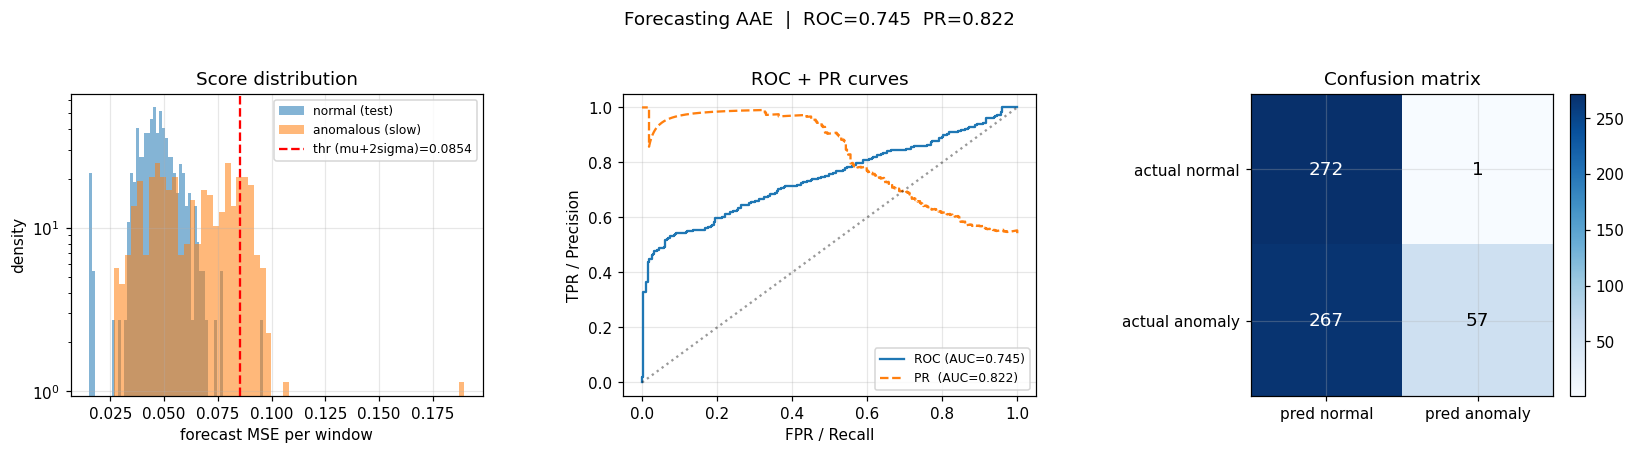

In [17]:
# Forecasting AAE score = mean MSE between generated future and true future.
fc_aae_sv = score_mean_mse(fc_aae_G, X_val_in,  X_val_tg)
fc_aae_st = score_mean_mse(fc_aae_G, X_test_in, X_test_tg)
fc_aae_ss = score_mean_mse(fc_aae_G, X_slow_in, X_slow_tg)

print(f"val_normal   n={fc_aae_sv.size:4d}  mean={fc_aae_sv.mean():.5f}  p99={np.percentile(fc_aae_sv, 99):.5f}")
print(f"test_normal  n={fc_aae_st.size:4d}  mean={fc_aae_st.mean():.5f}  p99={np.percentile(fc_aae_st, 99):.5f}")
print(f"slow         n={fc_aae_ss.size:4d}  mean={fc_aae_ss.mean():.5f}  p99={np.percentile(fc_aae_ss, 99):.5f}")
print()

fc_aae_res = evaluate_scores(fc_aae_sv, fc_aae_st, fc_aae_ss, tag="Forecasting AAE")
print_headline(fc_aae_res)
plot_diagnostics(fc_aae_res, score_label="forecast MSE per window")

### 10.2 Forecasting AE vs Forecasting AAE

                 model |  ROC-AUC |  PR-AUC | thr (mu+2sig) |     P     R    F1 |  TP  FP  TN  FN
----------------------------------------------------------------------------------------------------
        Forecasting AE |   0.6512 |  0.7788 |       0.06833 | 0.913 0.454 0.606 | 147  14 259 177
       Forecasting AAE |   0.7446 |  0.8219 |       0.08538 | 0.983 0.176 0.298 |  57   1 272 267


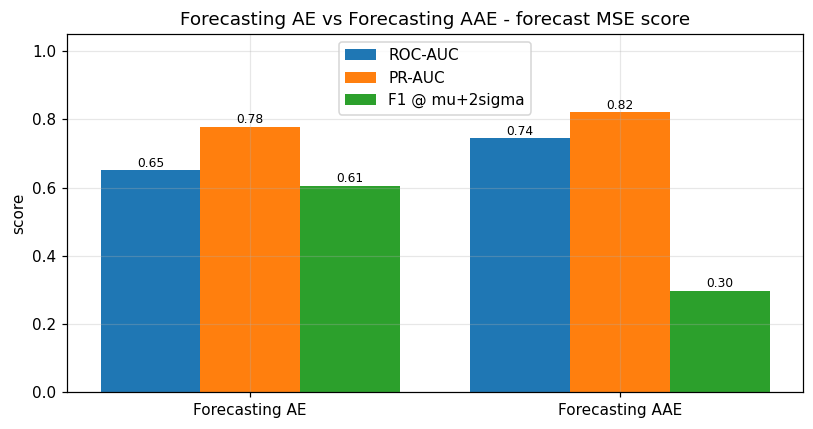


saved -> c:\Users\siava\Desktop\4th_Semester\ML-App\project-AM01\github_version\ML_APP_Anomaly_Detection\outputs\ae_compare\unsupervised\compare_forecast_aae.json

Forecasting AAE vs Forecasting AE:
  Delta ROC-AUC = +0.0934
  Delta PR-AUC  = +0.0431
  Delta F1      = -0.3078


In [18]:
forecast_adv_results = [fc_res, fc_aae_res]

print(f"{'model':>22s} | {'ROC-AUC':>8s} | {'PR-AUC':>7s} | "
      f"{'thr (mu+2sig)':>13s} | {'P':>5s} {'R':>5s} {'F1':>5s} | "
      f"{'TP':>3s} {'FP':>3s} {'TN':>3s} {'FN':>3s}")
print("-" * 100)
for r in forecast_adv_results:
    op = r["operating_points"]["mu+2sigma"]
    print(f"{r['tag']:>22s} | {r['roc_auc']:8.4f} | {r['pr_auc']:7.4f} | "
          f"{r['threshold']:13.5f} | {op['P']:5.3f} {op['R']:5.3f} {op['F1']:5.3f} | "
          f"{op['tp']:3d} {op['fp']:3d} {op['tn']:3d} {op['fn']:3d}")

labels = ["Forecasting AE", "Forecasting AAE"]
roc = [r["roc_auc"] for r in forecast_adv_results]
pr = [r["pr_auc"] for r in forecast_adv_results]
f1 = [r["operating_points"]["mu+2sigma"]["F1"] for r in forecast_adv_results]

x = np.arange(len(labels)); w = 0.27
fig, ax = plt.subplots(figsize=(7.5, 4))
ax.bar(x - w, roc, width=w, label="ROC-AUC")
ax.bar(x, pr, width=w, label="PR-AUC")
ax.bar(x + w, f1, width=w, label="F1 @ mu+2sigma")
for i, v in enumerate(roc): ax.text(i - w, v + 0.01, f"{v:.2f}", ha="center", fontsize=8)
for i, v in enumerate(pr): ax.text(i, v + 0.01, f"{v:.2f}", ha="center", fontsize=8)
for i, v in enumerate(f1): ax.text(i + w, v + 0.01, f"{v:.2f}", ha="center", fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylim(0.0, 1.05); ax.set_ylabel("score")
ax.set_title("Forecasting AE vs Forecasting AAE - forecast MSE score")
ax.legend(); plt.tight_layout(); plt.show()

summary_forecast_aae = {
    "config": {
        "window_len": WINDOW_LEN,
        "forecast_half": FORECAST_HALF,
        "enc_channels": list(ENC_CHANNELS),
        "batch_size": BATCH_SIZE,
        "epochs_cap": EPOCHS,
        "patience": PATIENCE,
        "fc_ae_lr": LEARNING_RATE,
        "fc_aae_lr_G": LR_G_FAAE,
        "fc_aae_lr_D": LR_D_FAAE,
        "fc_aae_lambda_adv": LAMBDA_ADV_FAAE,
        "inference_score": "forecast mean_MSE per window",
    },
    "models": {
        r["tag"]: {
            "roc_auc": r["roc_auc"],
            "pr_auc": r["pr_auc"],
            "operating_points": r["operating_points"],
        } for r in forecast_adv_results
    },
}
with open(OUTPUT_DIR / "compare_forecast_aae.json", "w", encoding="utf-8") as f:
    json.dump(summary_forecast_aae, f, indent=2, default=float)
print("\nsaved ->", OUTPUT_DIR / "compare_forecast_aae.json")

print("\nForecasting AAE vs Forecasting AE:")
print(f"  Delta ROC-AUC = {fc_aae_res['roc_auc'] - fc_res['roc_auc']:+.4f}")
print(f"  Delta PR-AUC  = {fc_aae_res['pr_auc'] - fc_res['pr_auc']:+.4f}")
print(f"  Delta F1      = {fc_aae_res['operating_points']['mu+2sigma']['F1'] - fc_res['operating_points']['mu+2sigma']['F1']:+.4f}")

### 10.3 Threshold sensitivity for forecasting models

In [19]:
TARGET_VAL_FALSE_ALARM_RATE = 0.10
CALIBRATED_PERCENTILE = int(round(100 * (1.0 - TARGET_VAL_FALSE_ALARM_RATE)))
CALIBRATED_RULE = f"p{CALIBRATED_PERCENTILE}"


def threshold_sensitivity_from_val(sv, st, ss, *, tag):
    """Evaluate label-free thresholds derived only from validation-normal scores."""
    y_eval = np.concatenate([np.zeros(st.size, np.int64), np.ones(ss.size, np.int64)])
    s_eval = np.concatenate([st, ss])

    candidates = {
        "mu+1sigma": float(sv.mean() + 1.0 * sv.std()),
        "mu+1.5sigma": float(sv.mean() + 1.5 * sv.std()),
        "mu+2sigma": float(sv.mean() + 2.0 * sv.std()),
        "mu+2.5sigma": float(sv.mean() + 2.5 * sv.std()),
        "mu+3sigma": float(sv.mean() + 3.0 * sv.std()),
        "p80": float(np.percentile(sv, 80)),
        "p85": float(np.percentile(sv, 85)),
        "p90": float(np.percentile(sv, 90)),
        "p95": float(np.percentile(sv, 95)),
        "p97": float(np.percentile(sv, 97)),
        "p99": float(np.percentile(sv, 99)),
    }

    rows = []
    for name, thr in candidates.items():
        pred = (s_eval > thr).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_eval, pred, labels=[0, 1]).ravel()
        P = tp / max(tp + fp, 1)
        R = tp / max(tp + fn, 1)
        F1 = 2 * P * R / max(P + R, 1e-12) if (P + R) > 0 else 0.0
        val_false_alarm_rate = float((sv > thr).mean())
        rows.append({"model": tag, "rule": name, "thr": float(thr),
                     "val_false_alarm_rate": val_false_alarm_rate,
                     "P": float(P), "R": float(R), "F1": float(F1),
                     "tp": int(tp), "fp": int(fp), "tn": int(tn), "fn": int(fn)})
    calibrated = next(r for r in rows if r["rule"] == CALIBRATED_RULE)
    return rows, calibrated


forecast_threshold_rows = []
forecast_threshold_calibrated = {}
for tag, sv, st, ss in [
    ("Forecasting AE", fc_sv, fc_st, fc_ss),
    ("Forecasting AAE", fc_aae_sv, fc_aae_st, fc_aae_ss),
]:
    rows, calibrated = threshold_sensitivity_from_val(sv, st, ss, tag=tag)
    forecast_threshold_rows.extend(rows)
    forecast_threshold_calibrated[tag] = calibrated

print("Threshold sensitivity: all thresholds are derived from val_normal scores")
print(f"Calibrated operating point: {CALIBRATED_RULE} "
      f"(target validation false-alarm rate = {TARGET_VAL_FALSE_ALARM_RATE:.0%})")
for tag in ["Forecasting AE", "Forecasting AAE"]:
    print(f"\n{tag}")
    print(f"{'rule':>12s} | {'thr':>9s} | {'val FA':>6s} | {'P':>5s} {'R':>5s} {'F1':>5s} | "
          f"{'TP':>3s} {'FP':>3s} {'TN':>3s} {'FN':>3s}")
    print("-" * 78)
    for row in [r for r in forecast_threshold_rows if r["model"] == tag]:
        star = " *" if row is forecast_threshold_calibrated[tag] else "  "
        print(f"{row['rule']:>12s} | {row['thr']:9.5f} | {row['val_false_alarm_rate']:6.1%} | "
              f"{row['P']:5.3f} {row['R']:5.3f} {row['F1']:5.3f} | "
              f"{row['tp']:3d} {row['fp']:3d} {row['tn']:3d} {row['fn']:3d}{star}")

    calibrated = forecast_threshold_calibrated[tag]
    print(f"Calibrated candidate for {tag}: {calibrated['rule']} "
          f"F1={calibrated['F1']:.3f}, P={calibrated['P']:.3f}, "
          f"R={calibrated['R']:.3f}, thr={calibrated['thr']:.5f}")

forecast_f1_summary = {
    "Forecasting AE": {
        "f1_mu2sigma": fc_res["operating_points"]["mu+2sigma"]["F1"],
        "calibrated_rule": forecast_threshold_calibrated["Forecasting AE"]["rule"],
        "calibrated_f1": forecast_threshold_calibrated["Forecasting AE"]["F1"],
    },
    "Forecasting AAE": {
        "f1_mu2sigma": fc_aae_res["operating_points"]["mu+2sigma"]["F1"],
        "calibrated_rule": forecast_threshold_calibrated["Forecasting AAE"]["rule"],
        "calibrated_f1": forecast_threshold_calibrated["Forecasting AAE"]["F1"],
    },
}

print("\nF1 summary used in the final plot")
for tag, vals in forecast_f1_summary.items():
    print(f"{tag}: F1@mu+2sigma={vals['f1_mu2sigma']:.3f} | "
          f"F1@calibrated({vals['calibrated_rule']})={vals['calibrated_f1']:.3f}")

summary_threshold_forecast = {
    "note": "Threshold candidates are derived from validation-normal scores; the calibrated threshold is selected by target validation false-alarm rate, not test F1.",
    "calibration": {
        "target_val_false_alarm_rate": TARGET_VAL_FALSE_ALARM_RATE,
        "calibrated_rule": CALIBRATED_RULE,
    },
    "primary_metrics": {
        "Forecasting AE": {"roc_auc": fc_res["roc_auc"], "pr_auc": fc_res["pr_auc"]},
        "Forecasting AAE": {"roc_auc": fc_aae_res["roc_auc"], "pr_auc": fc_aae_res["pr_auc"]},
    },
    "f1_summary": forecast_f1_summary,
    "rows": forecast_threshold_rows,
    "calibrated": forecast_threshold_calibrated,
}
with open(OUTPUT_DIR / "forecast_threshold_sensitivity.json", "w", encoding="utf-8") as f:
    json.dump(summary_threshold_forecast, f, indent=2, default=float)
print("\nsaved ->", OUTPUT_DIR / "forecast_threshold_sensitivity.json")


Threshold sensitivity: all thresholds are derived from val_normal scores
Calibrated operating point: p90 (target validation false-alarm rate = 10%)

Forecasting AE
        rule |       thr | val FA |     P     R    F1 |  TP  FP  TN  FN
------------------------------------------------------------------------------
   mu+1sigma |   0.05555 |   9.2% | 0.816 0.478 0.603 | 155  35 238 169  
 mu+1.5sigma |   0.06194 |   5.1% | 0.861 0.460 0.600 | 149  24 249 175  
   mu+2sigma |   0.06833 |   3.7% | 0.913 0.454 0.606 | 147  14 259 177  
 mu+2.5sigma |   0.07472 |   2.6% | 0.964 0.417 0.582 | 135   5 268 189  
   mu+3sigma |   0.08111 |   2.6% | 0.982 0.340 0.505 | 110   2 271 214  
         p80 |   0.04836 |  20.1% | 0.724 0.543 0.621 | 176  67 206 148  
         p85 |   0.05088 |  15.0% | 0.768 0.522 0.621 | 169  51 222 155  
         p90 |   0.05385 |  10.3% | 0.800 0.494 0.611 | 160  40 233 164 *
         p95 |   0.06173 |   5.1% | 0.856 0.460 0.598 | 149  25 248 175  
         p97 |   0.

### 10.4 Final forecasting comparison plot

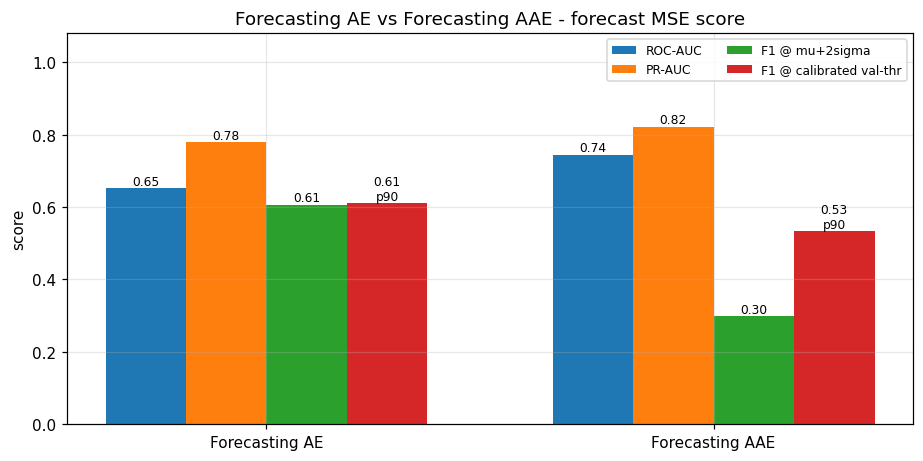

In [20]:
# Final headline plot: Forecasting AE vs Forecasting AAE.
# Shows threshold-free metrics plus two F1 operating points for each model.
forecast_adv_results = [fc_res, fc_aae_res]
labels = ["Forecasting AE", "Forecasting AAE"]
roc = [r["roc_auc"] for r in forecast_adv_results]
pr = [r["pr_auc"] for r in forecast_adv_results]
f1_mu2 = [r["operating_points"]["mu+2sigma"]["F1"] for r in forecast_adv_results]

# Requires the previous threshold-sensitivity cell. Recompute if needed.
if "forecast_threshold_calibrated" not in globals():
    forecast_threshold_rows = []
    forecast_threshold_calibrated = {}
    for tag, sv, st, ss in [
        ("Forecasting AE", fc_sv, fc_st, fc_ss),
        ("Forecasting AAE", fc_aae_sv, fc_aae_st, fc_aae_ss),
    ]:
        rows, calibrated = threshold_sensitivity_from_val(sv, st, ss, tag=tag)
        forecast_threshold_rows.extend(rows)
        forecast_threshold_calibrated[tag] = calibrated

f1_calibrated = [forecast_threshold_calibrated[label]["F1"] for label in labels]
calibrated_rules = [forecast_threshold_calibrated[label]["rule"] for label in labels]

x = np.arange(len(labels)); w = 0.18
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.bar(x - 1.5 * w, roc, width=w, label="ROC-AUC")
ax.bar(x - 0.5 * w, pr, width=w, label="PR-AUC")
ax.bar(x + 0.5 * w, f1_mu2, width=w, label="F1 @ mu+2sigma")
ax.bar(x + 1.5 * w, f1_calibrated, width=w, label="F1 @ calibrated val-thr")

for i, v in enumerate(roc): ax.text(i - 1.5 * w, v + 0.01, f"{v:.2f}", ha="center", fontsize=8)
for i, v in enumerate(pr): ax.text(i - 0.5 * w, v + 0.01, f"{v:.2f}", ha="center", fontsize=8)
for i, v in enumerate(f1_mu2): ax.text(i + 0.5 * w, v + 0.01, f"{v:.2f}", ha="center", fontsize=8)
for i, v in enumerate(f1_calibrated):
    ax.text(i + 1.5 * w, v + 0.01, f"{v:.2f}\n{calibrated_rules[i]}", ha="center", fontsize=8)

ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylim(0.0, 1.08); ax.set_ylabel("score")
ax.set_title("Forecasting AE vs Forecasting AAE - forecast MSE score")
ax.legend(ncol=2, fontsize=8)
plt.tight_layout(); plt.show()


## 11. Final summary - AE/AAE and Forecasting AE/AAE

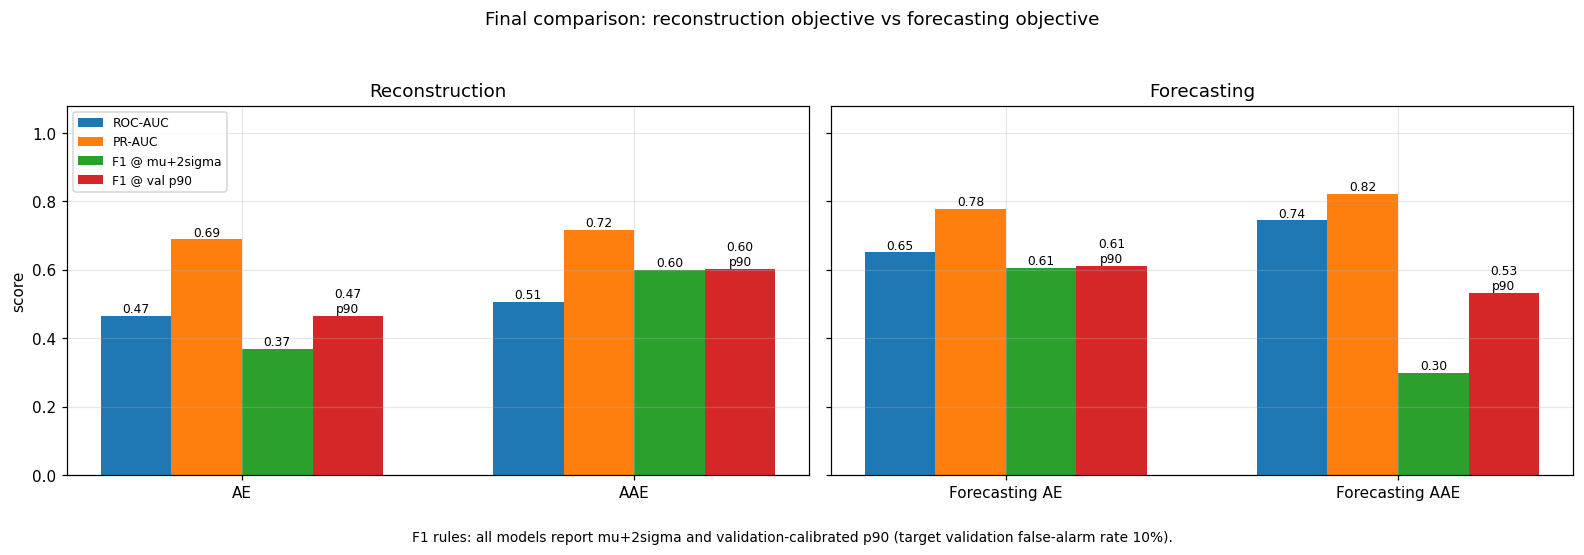

Final comparison table
F1 threshold note: F1 rules: all models report mu+2sigma and validation-calibrated p90 (target validation false-alarm rate 10%).
          group |            model |    ROC     PR  F1 mu2  F1 val | val rule
----------------------------------------------------------------------------------
 Reconstruction |               AE |  0.466  0.689   0.368   0.466 |      p90
 Reconstruction |              AAE |  0.507  0.717   0.599   0.603 |      p90
    Forecasting |   Forecasting AE |  0.651  0.779   0.606   0.611 |      p90
    Forecasting |  Forecasting AAE |  0.745  0.822   0.298   0.532 |      p90


In [21]:
# Final summary plot across both clean ablations.
# Reconstruction models use reconstruction MSE; forecasting models use forecast MSE.
# All models report the same two label-free F1 operating points.
final_groups = {
    "Reconstruction": [
        ("AE", recon_res,
         recon_res["operating_points"]["mu+2sigma"]["F1"],
         recon_res["operating_points"][CALIBRATED_RULE]["F1"], CALIBRATED_RULE),
        ("AAE", aae_res,
         aae_res["operating_points"]["mu+2sigma"]["F1"],
         aae_res["operating_points"][CALIBRATED_RULE]["F1"], CALIBRATED_RULE),
    ],
    "Forecasting": [
        ("Forecasting AE", fc_res,
         fc_res["operating_points"]["mu+2sigma"]["F1"],
         forecast_threshold_calibrated["Forecasting AE"]["F1"],
         forecast_threshold_calibrated["Forecasting AE"]["rule"]),
        ("Forecasting AAE", fc_aae_res,
         fc_aae_res["operating_points"]["mu+2sigma"]["F1"],
         forecast_threshold_calibrated["Forecasting AAE"]["F1"],
         forecast_threshold_calibrated["Forecasting AAE"]["rule"]),
    ],
}

threshold_note = (
    f"F1 rules: all models report mu+2sigma and validation-calibrated {CALIBRATED_RULE} "
    f"(target validation false-alarm rate {TARGET_VAL_FALSE_ALARM_RATE:.0%})."
)

fig, axes = plt.subplots(1, 2, figsize=(14.5, 4.8), sharey=True)
bar_w = 0.18

for ax, (group_name, entries) in zip(axes, final_groups.items()):
    labels = [e[0] for e in entries]
    roc = [e[1]["roc_auc"] for e in entries]
    pr = [e[1]["pr_auc"] for e in entries]
    f1_mu2 = [e[2] for e in entries]
    f1_calibrated = [e[3] for e in entries]
    f1_rules = [e[4] for e in entries]
    x = np.arange(len(labels))

    ax.bar(x - 1.5 * bar_w, roc, width=bar_w, label="ROC-AUC")
    ax.bar(x - 0.5 * bar_w, pr, width=bar_w, label="PR-AUC")
    ax.bar(x + 0.5 * bar_w, f1_mu2, width=bar_w, label="F1 @ mu+2sigma")
    ax.bar(x + 1.5 * bar_w, f1_calibrated, width=bar_w, label=f"F1 @ val {CALIBRATED_RULE}")

    for i, v in enumerate(roc):
        ax.text(i - 1.5 * bar_w, v + 0.01, f"{v:.2f}", ha="center", fontsize=8)
    for i, v in enumerate(pr):
        ax.text(i - 0.5 * bar_w, v + 0.01, f"{v:.2f}", ha="center", fontsize=8)
    for i, v in enumerate(f1_mu2):
        ax.text(i + 0.5 * bar_w, v + 0.01, f"{v:.2f}", ha="center", fontsize=8)
    for i, v in enumerate(f1_calibrated):
        ax.text(i + 1.5 * bar_w, v + 0.01, f"{v:.2f}\n{f1_rules[i]}", ha="center", fontsize=8)

    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_ylim(0.0, 1.08)
    ax.set_title(group_name)
    ax.grid(True, axis="y", alpha=0.3)

axes[0].set_ylabel("score")
axes[0].legend(loc="upper left", fontsize=8)
fig.suptitle("Final comparison: reconstruction objective vs forecasting objective", y=1.02)
fig.text(0.5, 0.015, threshold_note, ha="center", fontsize=9)
plt.tight_layout(rect=(0, 0.06, 1, 0.98)); plt.show()

print("Final comparison table")
print("F1 threshold note:", threshold_note)
print(f"{'group':>15s} | {'model':>16s} | {'ROC':>6s} {'PR':>6s} "
      f"{'F1 mu2':>7s} {'F1 val':>7s} | {'val rule':>8s}")
print("-" * 82)
for group_name, entries in final_groups.items():
    for model_name, res, f1_mu2_value, f1_calibrated_value, f1_rule in entries:
        print(f"{group_name:>15s} | {model_name:>16s} | "
              f"{res['roc_auc']:6.3f} {res['pr_auc']:6.3f} "
              f"{f1_mu2_value:7.3f} {f1_calibrated_value:7.3f} | {f1_rule:>8s}")

## 12. Point-adjusted F1 evaluation

Optional event-level sanity check. One point here means one scored evaluation window, not one raw timestep. Classic point adjustment can be optimistic for this dataset because the slow test block is treated as one continuous anomaly event, so keep ROC-AUC, PR-AUC, and raw/window-level F1 as the main results.


In [22]:
# Point adjustment is post-processing of frozen threshold predictions.
# A point is one evaluation window because each model produces one score per window.
# The current test vector is [test_normal windows, slow_test windows], so the
# slow-test block is treated as one continuous ground-truth anomaly event.

from pathlib import Path
import json
import numpy as np
from sklearn.metrics import confusion_matrix

if "OUTPUT_DIR" not in globals():
    OUTPUT_DIR = Path.cwd() / "outputs" / "ae_compare" / "unsupervised"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

POINT_ADJUSTMENT_KS = (0.25, 0.50, 0.75)
PA_THRESHOLD_RULES = list(dict.fromkeys(["mu+2sigma", globals().get("CALIBRATED_RULE", "p90")]))


def find_anomaly_events(y_true):
    """Return half-open [start, end) ranges of contiguous positive labels."""
    y_true = np.asarray(y_true, dtype=np.int64)
    padded = np.pad(y_true, (1, 1), constant_values=0)
    transitions = np.diff(padded)
    starts = np.flatnonzero(transitions == 1)
    ends = np.flatnonzero(transitions == -1)
    return list(zip(starts, ends))


def binary_f1_stats(y_true, y_pred):
    """Anomaly-class precision, recall, F1, and confusion-matrix counts."""
    y_true = np.asarray(y_true, dtype=np.int64)
    y_pred = np.asarray(y_pred, dtype=np.int64)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    precision = tp / max(tp + fp, 1)
    recall = tp / max(tp + fn, 1)
    f1 = 2 * precision * recall / max(precision + recall, 1e-12) if precision + recall > 0 else 0.0
    return {
        "P": float(precision), "R": float(recall), "F1": float(f1),
        "tp": int(tp), "fp": int(fp), "tn": int(tn), "fn": int(fn),
    }


def apply_point_adjustment(y_true, y_pred, *, min_event_coverage=None):
    """Apply classic PA or fill-only K%-PA while retaining false positives."""
    y_true = np.asarray(y_true, dtype=np.int64)
    y_pred = np.asarray(y_pred, dtype=np.int64)
    adjusted = y_pred.copy()
    event_rows = []

    for event_id, (start, end) in enumerate(find_anomaly_events(y_true), start=1):
        event_len = int(end - start)
        detected = int(y_pred[start:end].sum())
        coverage = detected / max(event_len, 1)
        required = 1 if min_event_coverage is None else int(np.ceil(min_event_coverage * event_len))
        qualifies = detected >= required
        if qualifies:
            adjusted[start:end] = 1
        event_rows.append({
            "event_id": event_id, "start": int(start), "end": int(end),
            "event_length": event_len, "detected_windows": detected,
            "coverage": float(coverage), "required_windows": int(required),
            "qualifies": bool(qualifies),
        })

    return adjusted, event_rows


def point_adjustment_f1_row(group, model_name, res, threshold_rule, threshold_source):
    """Compute raw, classic-PA, and K%-PA F1 for one frozen threshold."""
    missing = [key for key in ("operating_points", "y_eval", "s_eval") if key not in res]
    if missing:
        raise KeyError(
            f"{res.get('tag', model_name)} is missing {missing}. "
            "PA needs the in-memory evaluation result, not the compact saved JSON."
        )
    if threshold_rule not in res["operating_points"]:
        raise KeyError(f"{res.get('tag', model_name)} has no threshold rule {threshold_rule!r}")

    thr = float(res["operating_points"][threshold_rule]["thr"])
    y_true = np.asarray(res["y_eval"], dtype=np.int64)
    raw_pred = (np.asarray(res["s_eval"]) > thr).astype(np.int64)
    raw_stats = binary_f1_stats(y_true, raw_pred)
    classic_pred, classic_events = apply_point_adjustment(y_true, raw_pred)

    adjusted_stats = {}
    adjusted_events = {}
    for k in POINT_ADJUSTMENT_KS:
        label = f"PA_K{int(k * 100)}"
        adjusted_pred, events = apply_point_adjustment(y_true, raw_pred, min_event_coverage=k)
        adjusted_stats[label] = binary_f1_stats(y_true, adjusted_pred)
        adjusted_events[label] = events

    coverages = [event["coverage"] for event in classic_events]
    return {
        "group": group, "model": model_name, "notebook_tag": res.get("tag", model_name),
        "threshold_source": threshold_source, "threshold_rule": threshold_rule,
        "threshold": thr, "raw": raw_stats,
        "classic_PA": binary_f1_stats(y_true, classic_pred),
        **adjusted_stats,
        "n_events": len(classic_events),
        "mean_event_coverage_before_PA": float(np.mean(coverages)) if coverages else 0.0,
        "events": {"classic_PA": classic_events, **adjusted_events},
    }


def _pa_stat(row, key):
    return row.get(key, row.get(key.replace("PA_K", "PA%K"), {"F1": float("nan")}))


def print_point_adjustment_table(rows, title, threshold_note=None):
    print(title)
    print("One point = one test window; point adjustment is applied after threshold selection.")
    if threshold_note:
        print(threshold_note)
    print(f"{'group':>15s} | {'model':>16s} | {'threshold':>10s} | {'raw F1':>7s} "
          f"{'classic':>8s} {'PA_K25':>7s} {'PA_K50':>7s} {'PA_K75':>7s} | "
          f"{'raw coverage':>12s} {'events':>6s}")
    print("-" * 112)
    for row in rows:
        print(f"{row['group']:>15s} | {row['model']:>16s} | {row['threshold_rule']:>10s} | "
              f"{row['raw']['F1']:7.3f} {row['classic_PA']['F1']:8.3f} "
              f"{_pa_stat(row, 'PA_K25')['F1']:7.3f} {_pa_stat(row, 'PA_K50')['F1']:7.3f} "
              f"{_pa_stat(row, 'PA_K75')['F1']:7.3f} | "
              f"{row['mean_event_coverage_before_PA']:12.1%} {row['n_events']:6d}")


required_results = {
    "recon_res": ("Reconstruction", "AE"),
    "aae_res": ("Reconstruction", "AAE"),
    "fc_res": ("Forecasting", "Forecasting AE"),
    "fc_aae_res": ("Forecasting", "Forecasting AAE"),
}
missing_results = [name for name in required_results if name not in globals()]
point_adjustment_path = OUTPUT_DIR / "point_adjustment_f1_summary.json"

if missing_results and point_adjustment_path.is_file():
    point_adjustment_summary = json.loads(point_adjustment_path.read_text(encoding="utf-8"))
    point_adjustment_rows = point_adjustment_summary["rows"]
    print_point_adjustment_table(
        point_adjustment_rows,
        "Point-adjusted F1 table (loaded from saved JSON)",
        f"loaded -> {point_adjustment_path}",
    )
elif missing_results:
    raise RuntimeError(
        "Point-adjusted F1 needs these in-memory result variables: "
        + ", ".join(missing_results)
        + ". Run the evaluation/final-result cells that create them; model training does not need to be repeated if those variables are still available or checkpoints are loaded."
    )
else:
    # AAE v2 is intentionally omitted here to match the final summary plot.
    pa_models = [
        (group, model_name, globals()[result_name])
        for result_name, (group, model_name) in required_results.items()
    ]

    point_adjustment_rows = []
    for group, model_name, res in pa_models:
        for rule in PA_THRESHOLD_RULES:
            source = "val_normal mu+2sigma" if rule == "mu+2sigma" else "val_normal calibrated percentile"
            point_adjustment_rows.append(point_adjustment_f1_row(group, model_name, res, rule, source))

    point_adjustment_summary = {
        "note": ("Window-level, fill-only point adjustment on test_normal + slow_test. "
                 "False positives outside true anomaly events are retained."),
        "threshold_rules": PA_THRESHOLD_RULES,
        "k_percentages": list(POINT_ADJUSTMENT_KS),
        "rows": point_adjustment_rows,
    }
    with open(point_adjustment_path, "w", encoding="utf-8") as f:
        json.dump(point_adjustment_summary, f, indent=2, default=float)

    print_point_adjustment_table(
        point_adjustment_rows,
        "Point-adjusted F1 table (unsupervised notebook)",
        f"Threshold rules evaluated: {', '.join(PA_THRESHOLD_RULES)}",
    )
    print("\nsaved ->", point_adjustment_path)


Point-adjusted F1 table (unsupervised notebook)
One point = one test window; point adjustment is applied after threshold selection.
Threshold rules evaluated: mu+2sigma, p90
          group |            model |  threshold |  raw F1  classic  PA_K25  PA_K50  PA_K75 | raw coverage events
----------------------------------------------------------------------------------------------------------------
 Reconstruction |               AE |  mu+2sigma |   0.368    1.000   0.368   0.368   0.368 |        22.5%      1
 Reconstruction |               AE |        p90 |   0.466    0.992   0.992   0.466   0.466 |        30.9%      1
 Reconstruction |              AAE |  mu+2sigma |   0.599    0.998   0.998   0.599   0.599 |        42.9%      1
 Reconstruction |              AAE |        p90 |   0.603    0.992   0.992   0.603   0.603 |        43.8%      1
    Forecasting |   Forecasting AE |  mu+2sigma |   0.606    0.979   0.979   0.606   0.606 |        45.4%      1
    Forecasting |   Forecasting AE 